<a href="https://colab.research.google.com/github/sidms24/AML/blob/main/notebooks/sirs_sirc_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIRS/SIRC Epidemic Model — Latent-Informed Drift Scores

Compares **VAE** and **TransformerVAE** latent representations as drift signals
fed into a SIRC compartmental model to predict flu hospitalisation rates.

In [1]:
import os
if not os.path.exists('models'):
    !git clone https://github.com/sidms24/AML.git
    os.chdir('AML')
!pip install -q -r requirements.txt

Cloning into 'AML'...
remote: Enumerating objects: 762, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 762 (delta 161), reused 72 (delta 72), pack-reused 555 (from 1)
Receiving objects: 100% (762/762), 24.55 MiB | 36.07 MiB/s, done.
Resolving deltas: 100% (493/493), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.7 MB/s eta 0:00:00


In [2]:

HF_REPO = 'sidms/AML'
HF_BASE = f'https://huggingface.co/datasets/{HF_REPO}/resolve/main'
COVID_SEASON = '2020-21'
PANDEMIC_SEASON = '2009-10'  # H1N1 pandemic — exclude like Perofsky et al.
# we calibrate on earlier seasons and hold out recent ones for validation
CALIB_SEASONS = [f'{y}-{str(y+1)[-2:]}' for y in range(2008, 2018)]
VALID_SEASONS = [f'{y}-{str(y+1)[-2:]}' for y in range(2018, 2024)]
BATCH_SIZE = 64
CALIB_STEPS = 100
CALIB_LR = 0.05

os.makedirs('figures_sirs', exist_ok=True)
os.makedirs('results', exist_ok = True)

In [3]:
from tqdm import tqdm
# force plain text progress bars before importing HF libraries
import tqdm.auto, tqdm.std
tqdm.auto.tqdm = tqdm.std.tqdm
import torch
import numpy as np
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import hamming
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('AML')

import jax
import jax.numpy as jnp
print(f'JAX devices: {jax.devices()}')

from models.vae import VAE
from models.transformer_vae import TransformerVAE
from utils.dataloader import load_data
from utils.encoders import dna_one_hot
from utils.drift import (
    compute_drift_scores, assign_season, compute_blended_drift,
    compute_latent_diversity, validate_latent_drift,
)
from utils.sirc import (
    simulate_season, simulate_batch, calibrate, calibrate_multistart,
    calibrate_loo_cv, constrain_params, drift_to_s0,
    BETA_FIXED, GAMMA_FIXED, MU_FIXED, SIGMA_FIXED, DELTA_FIXED,
)
from utils.sirc_helpers import (
    load_vae_from_hf, load_tvae_from_hf,
    extract_vae_latents, extract_tvae_latents,
    compute_hamming_drift, get_raw_sequences,
    load_cdc_csv, bootstrap_corr,
    build_sim_results, eval_metrics, compute_metrics,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device: {device}')
print(f'Calibration: {CALIB_SEASONS[0]} -> {CALIB_SEASONS[-1]}')
print(f'Validation:  {VALID_SEASONS[0]} -> {VALID_SEASONS[-1]}')
print(f'SIRC beta fixed at {BETA_FIXED:.2f}')


JAX devices: [CudaDevice(id=0)]
PyTorch device: cuda
Calibration: 2008-09 -> 2017-18
Validation:  2018-19 -> 2023-24
SIRC beta fixed at 0.30


## Step 1: Load Trained Models (VAE + TransformerVAE)

In [4]:
vae_h1n1, vcfg_h1n1, vhist_h1n1 = load_vae_from_hf('vae_h1n1_weights.pt')
vae_h3n2, vcfg_h3n2, vhist_h3n2 = load_vae_from_hf('vae_h3n2_weights.pt')

In [5]:
tvae_h1n1, tcfg_h1n1, thist_h1n1 = load_tvae_from_hf('tvae_h1n1_weights.pt')
tvae_h3n2, tcfg_h3n2, thist_h3n2 = load_tvae_from_hf('tvae_h3n2_weights.pt')

## Step 2: Extract Latents & Compute Drift Scores

In [7]:
z_vae_h1n1, years_vae_h1n1, seasons_vae_h1n1, _ = extract_vae_latents(vae_h1n1, 'H1N1_drift')
print(f'  H1N1: {z_vae_h1n1.shape[0]} sequences, {z_vae_h1n1.shape[1]}-dim latent')
z_vae_h3n2, years_vae_h3n2, seasons_vae_h3n2,_ = extract_vae_latents(vae_h3n2, 'H3N2_drift')
print(f'  H3N2: {z_vae_h3n2.shape[0]} sequences, {z_vae_h3n2.shape[1]}-dim latent')

  H1N1: 25760 sequences, 64-dim latent


Map (num_proc=4): 100%|██████████| 38109/38109 [00:07<00:00, 4778.58 examples/s]


  H3N2: 38109 sequences, 64-dim latent


In [8]:
z_tvae_h1n1, years_tvae_h1n1, seasons_tvae_h1n1,_ = extract_tvae_latents(tvae_h1n1, 'H1N1_drift')
print(f'  H1N1: {z_tvae_h1n1.shape[0]} sequences, {z_tvae_h1n1.shape[1]}-dim latent')

z_tvae_h3n2, years_tvae_h3n2, seasons_tvae_h3n2,_ = extract_tvae_latents(tvae_h3n2, 'H3N2_drift')
print(f'  H3N2: {z_tvae_h3n2.shape[0]} sequences, {z_tvae_h3n2.shape[1]}-dim latent')

  H1N1: 25760 sequences, 128-dim latent
  H3N2: 38109 sequences, 128-dim latent


In [9]:
# VAE drift scores — now using season-aware grouping from seq_data.ipynb
# the season labels come from the HF dataset (month-aware MMWR assignment)
# expanding-window normalisation prevents data leakage from future seasons
drift_vae_h1n1 = compute_drift_scores(z_vae_h1n1, years_vae_h1n1,
                                      seasons=seasons_vae_h1n1
                                       )
drift_vae_h1n1['subtype'] = 'H1N1'

drift_vae_h3n2 = compute_drift_scores(z_vae_h3n2, years_vae_h3n2,
                                      seasons=seasons_vae_h3n2)
drift_vae_h3n2['subtype'] = 'H3N2'

print('VAE H1N1 drift scores:')
display(drift_vae_h1n1[['season', 'drift_raw', 'drift_norm', 'n_sequences']].tail(10))
print('\nVAE H3N2 drift scores:')
display(drift_vae_h3n2[['season', 'drift_raw', 'drift_norm', 'n_sequences']].tail(10))

# VAE lag-2 drift: compare season t to season t-2 instead of t-1
# Perofsky et al. 2024 found this outperforms lag-1 for HA epitope distance
drift_vae_h1n1_lag2 = compute_drift_scores(z_vae_h1n1, years_vae_h1n1,
                                           seasons=seasons_vae_h1n1, lag=2)
drift_vae_h3n2_lag2 = compute_drift_scores(z_vae_h3n2, years_vae_h3n2,
                                           seasons=seasons_vae_h3n2, lag=2)
print('\nVAE lag-2 H3N2 drift:')
display(drift_vae_h3n2_lag2[['season', 'drift_raw', 'drift_norm', 'n_sequences']].tail(8))

# VAE latent diversity — mean distance from centroid within each season
div_vae_h3n2 = compute_latent_diversity(z_vae_h3n2, seasons_vae_h3n2)
div_vae_h1n1 = compute_latent_diversity(z_vae_h1n1, seasons_vae_h1n1)
print('\nVAE H3N2 latent diversity:')
display(div_vae_h3n2[['season', 'latent_spread', 'latent_var_trace', 'n_sequences']].tail(8))


VAE H1N1 drift scores:


,season,drift_raw,drift_norm,n_sequences
7,2016-17,1.540735,0.000000,548
8,2017-18,2.739396,0.279914,1173
9,2018-19,1.409277,0.000000,2509
10,2019-20,1.965778,0.126085,2032
11,2020-21,2.792157,0.313314,12
12,2021-22,2.985838,0.357196,105
13,2022-23,2.082007,0.152418,2170
14,2023-24,1.116446,0.000000,6859
15,2024-25,1.897124,0.165871,6310
16,2025-26,2.737940,0.344519,357



VAE H3N2 drift scores:


,season,drift_raw,drift_norm,n_sequences
7,2016-17,2.128811,0.092894,2591
8,2017-18,2.309144,0.133897,2572
9,2018-19,3.423725,0.387318,3863
10,2019-20,3.674911,0.444430,929
11,2020-21,3.497066,0.403993,82
12,2021-22,0.980507,0.000000,5132
13,2022-23,2.239917,0.245123,3829
14,2023-24,3.431684,0.477080,5106
15,2024-25,1.333200,0.068646,7078
16,2025-26,3.337307,0.458711,2621



VAE lag-2 H3N2 drift:


,season,drift_raw,drift_norm,n_sequences
8,2018-19,3.235538,0.350111,3863
9,2019-20,3.703335,0.502479,929
10,2020-21,4.142056,0.645377,82
11,2021-22,3.756207,0.519700,5132
12,2022-23,2.334928,0.056768,3829
13,2023-24,3.292020,0.368508,5106
14,2024-25,3.448671,0.419531,7078
15,2025-26,3.314375,0.375789,2621



VAE H3N2 latent diversity:


,season,latent_spread,latent_var_trace,n_sequences
10,2018-19,3.669112,15.090942,3863
11,2019-20,4.588271,22.017797,929
12,2020-21,2.942632,11.473288,82
13,2021-22,2.817725,9.822348,5132
14,2022-23,3.442271,13.082690,3829
15,2023-24,3.200203,11.649230,5106
16,2024-25,3.591274,14.308627,7078
17,2025-26,2.646245,8.060856,2621


In [10]:
# TransformerVAE drift scores — same pipeline, third architecture
drift_tvae_h1n1 = compute_drift_scores(z_tvae_h1n1, years_tvae_h1n1,
                                        seasons=seasons_tvae_h1n1
                                       )
drift_tvae_h3n2 = compute_drift_scores(z_tvae_h3n2, years_tvae_h3n2,
                                        seasons=seasons_tvae_h3n2)

print('TVAE H1N1 drift scores:\n')
display(drift_tvae_h1n1[['season', 'drift_raw', 'drift_norm', 'n_sequences']].tail(10))
print('\nTVAE H3N2 drift scores:\n')
display(drift_tvae_h3n2[['season', 'drift_raw', 'drift_norm', 'n_sequences']].tail(10))


TVAE H1N1 drift scores:



,season,drift_raw,drift_norm,n_sequences
7,2016-17,1.176571,0.000000,548
8,2017-18,4.521249,0.643797,1173
9,2018-19,2.900098,0.331751,2509
10,2019-20,3.716646,0.488924,2032
11,2020-21,4.635569,0.665801,12
12,2021-22,3.436340,0.434969,105
13,2022-23,2.719891,0.297064,2170
14,2023-24,2.048058,0.167747,6859
15,2024-25,2.390055,0.233576,6310
16,2025-26,4.347360,0.610326,357



TVAE H3N2 drift scores:



,season,drift_raw,drift_norm,n_sequences
7,2016-17,2.947984,0.314238,2591
8,2017-18,3.322415,0.521934,2572
9,2018-19,3.636611,0.696217,3863
10,2019-20,4.122632,0.965811,929
11,2020-21,4.251068,1.000000,82
12,2021-22,1.676668,0.000000,5132
13,2022-23,2.184323,0.197194,3829
14,2023-24,3.448785,0.688361,5106
15,2024-25,0.785272,0.000000,7078
16,2025-26,4.030556,0.936375,2621


## Step 2b: Lag-2 Drift Scores (Perofsky-Inspired)

Perofsky et al. (2024) found that **2-season lag** HA epitope distance is a stronger
predictor of epidemic size than 1-season lag. We compute lag-2 latent drift to test
whether this holds for learned representations too.

In [11]:
# TVAE lag-2 drift
drift_tvae_h1n1_lag2 = compute_drift_scores(z_tvae_h1n1, years_tvae_h1n1,
                                             seasons=seasons_tvae_h1n1,
                                              lag=2)
drift_tvae_h3n2_lag2 = compute_drift_scores(z_tvae_h3n2, years_tvae_h3n2,
                                             seasons=seasons_tvae_h3n2,
                                            lag=2)
print('Lag-2 TVAE H3N2 drift:\n')
display(drift_tvae_h3n2_lag2[['season', 'drift_raw', 'drift_norm']].tail(8))


Lag-2 TVAE H3N2 drift:



,season,drift_raw,drift_norm
8,2018-19,3.868335,0.506552
9,2019-20,4.480505,0.744592
10,2020-21,4.456465,0.735244
11,2021-22,4.091445,0.593307
12,2022-23,2.496410,0.000000
13,2023-24,3.320374,0.311998
14,2024-25,3.493092,0.377398
15,2025-26,4.380440,0.713396


## Step 2c: Latent Diversity (Intra-Season Spread)

Analogous to Perofsky et al.'s LBI Shannon entropy — measures whether a season has
one dominant variant or many co-circulating lineages. High latent spread = more
sequence diversity within the season.

In [12]:
# TVAE latent diversity
div_tvae_h3n2 = compute_latent_diversity(z_tvae_h3n2, seasons_tvae_h3n2)
print('TVAE H3N2 — latent diversity:\n')
display(div_tvae_h3n2[['season', 'latent_spread', 'latent_var_trace', 'n_sequences']].tail(8))


TVAE H3N2 — latent diversity:



,season,latent_spread,latent_var_trace,n_sequences
10,2018-19,3.491283,15.424392,3863
11,2019-20,4.975693,26.252611,929
12,2020-21,3.402500,15.843378,82
13,2021-22,2.335762,9.082552,5132
14,2022-23,2.531477,10.603744,3829
15,2023-24,0.958829,4.509644,5106
16,2024-25,2.454810,14.043728,7078
17,2025-26,1.006941,4.527084,2621


## Step 2d: Epitope Hamming Distance Baseline

Perofsky et al.'s strongest predictor was Hamming distance at **129 known HA epitope sites**
(Wolf et al.). We compute a simple whole-sequence Hamming distance between season consensus
sequences as a non-ML baseline to benchmark our autoencoder drift against.

In [13]:
# epitope Hamming baseline — how much does the raw consensus sequence change?
# we compute per-position majority vote per season, then Hamming distance between seasons
# this is the "dumb baseline" our autoencoders need to beat

raw_h3n2, raw_seasons_h3n2 = get_raw_sequences('H3N2_drift', batch_size=BATCH_SIZE)
raw_h1n1, raw_seasons_h1n1 = get_raw_sequences('H1N1_drift', batch_size=BATCH_SIZE)

hamming_h3n2 = compute_hamming_drift(raw_h3n2, raw_seasons_h3n2, lag=1)
hamming_h3n2_lag2 = compute_hamming_drift(raw_h3n2, raw_seasons_h3n2, lag=2)
hamming_h1n1 = compute_hamming_drift(raw_h1n1, raw_seasons_h1n1, lag=1)
hamming_h1n1_lag2 = compute_hamming_drift(raw_h1n1, raw_seasons_h1n1, lag=2)

print(f'H3N2 Hamming drift (lag-1): {len(hamming_h3n2)} seasons')
display(hamming_h3n2.tail(6))

H3N2 Hamming drift (lag-1): 17 seasons


,season,hamming_raw,hamming_norm
11,2020-21,0.017799,0.571429
12,2021-22,0.000000,0.000000
13,2022-23,0.012406,0.403509
14,2023-24,0.016181,0.526316
15,2024-25,0.000539,0.017544
16,2025-26,0.010248,0.333333


In [14]:
# BLOCKER fix: validate latent drift against epitope Hamming baseline
# this checks whether the autoencoder captures biologically meaningful variation
# note: this is NOT a gold-standard antigenic validation (we lack HI titer data)
from utils.drift import validate_latent_drift

print('=== VAE Latent Drift vs Hamming Baseline ===')
print('H3N2:')
val_h3n2 = validate_latent_drift(drift_vae_h3n2, hamming_h3n2, on='season')
print()
print('H1N1 (if Hamming available):')
try:
    val_h1n1 = validate_latent_drift(drift_vae_h1n1, hamming_h1n1, on='season')
except NameError:
    print('  Hamming baseline not computed for H1N1 — skipping')

print()
print('=== TVAE Latent Drift vs Hamming Baseline ===')
print('H3N2:')
val_tvae_h3n2 = validate_latent_drift(drift_tvae_h3n2, hamming_h3n2, on='season')

=== VAE Latent Drift vs Hamming Baseline ===
H3N2:
Latent vs Hamming drift validation:
  Spearman rho = 0.595 (p = 0.0117)
  95% bootstrap CI: [0.017, 0.936]
  n = 17 seasons

H1N1 (if Hamming available):
Latent vs Hamming drift validation:
  Spearman rho = 0.617 (p = 0.0083)
  95% bootstrap CI: [0.176, 0.851]
  n = 17 seasons

=== TVAE Latent Drift vs Hamming Baseline ===
H3N2:
Latent vs Hamming drift validation:
  Spearman rho = 0.636 (p = 0.0061)
  95% bootstrap CI: [0.147, 0.876]
  n = 17 seasons


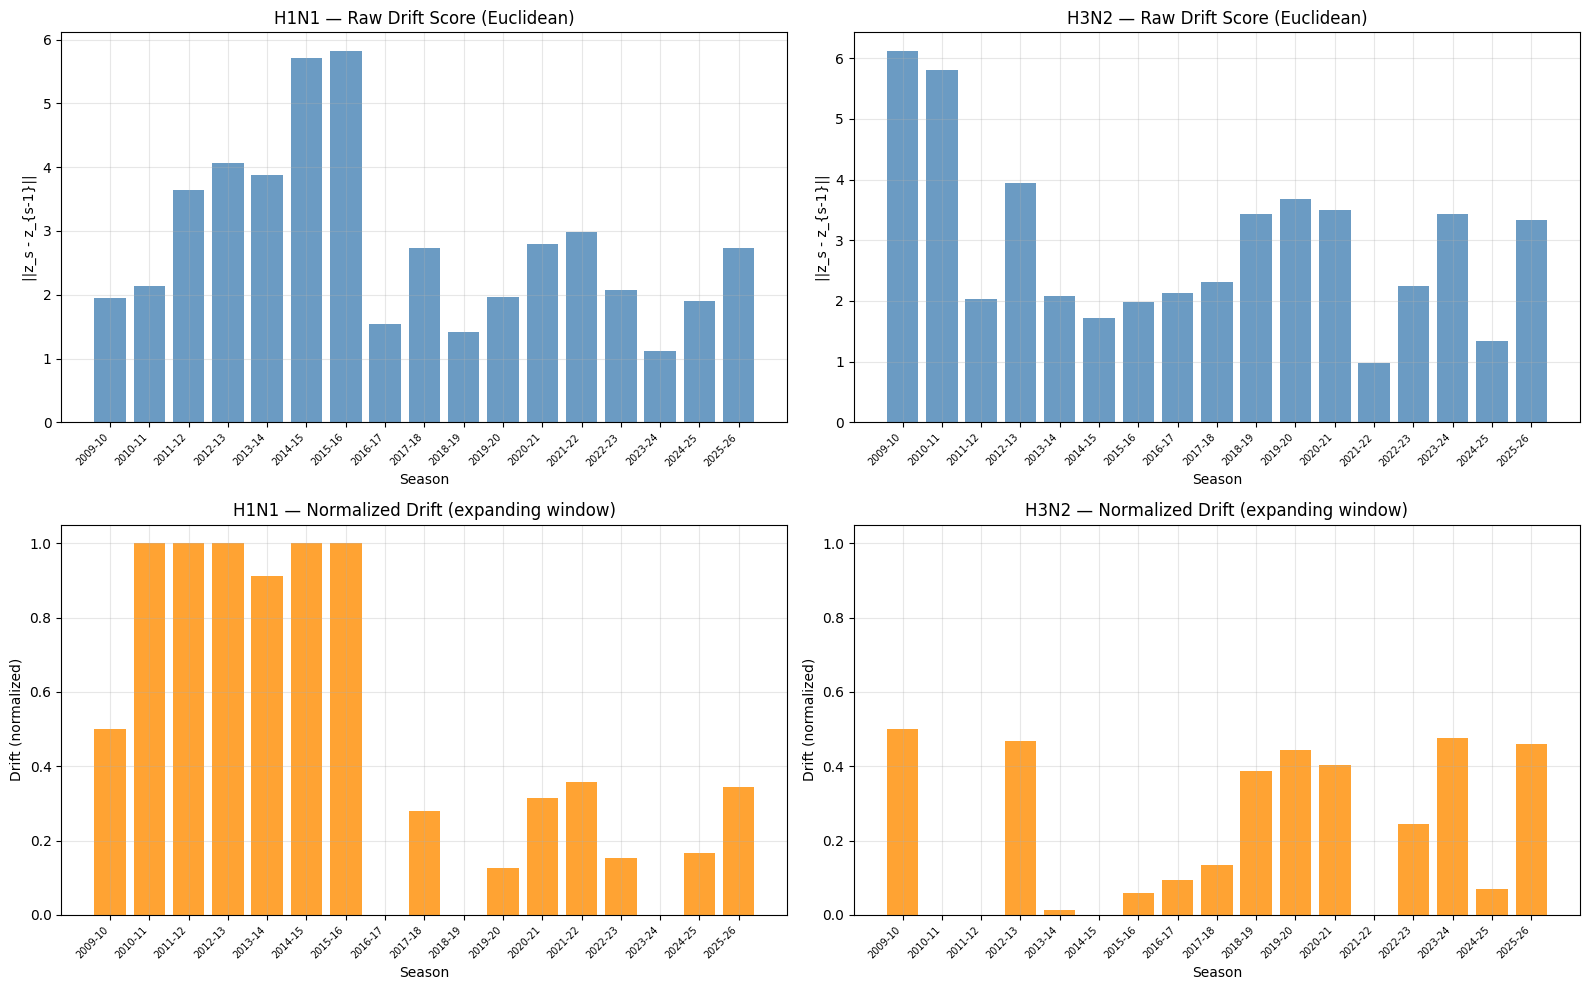

In [15]:
# raw vs normalised drift — now grouped by season (not year)
# we expect H3N2 to show more season-over-season movement
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, df, name in [(axes[0, 0], drift_vae_h1n1, 'H1N1'), (axes[0, 1], drift_vae_h3n2, 'H3N2')]:
    ax.bar(range(len(df)), df['drift_raw'], color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['season'], rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{name} — Raw Drift Score (Euclidean)')
    ax.set_xlabel('Season')
    ax.set_ylabel('||z_s - z_{s-1}||')
    ax.grid(True, alpha=0.3)

for ax, df, name in [(axes[1, 0], drift_vae_h1n1, 'H1N1'), (axes[1, 1], drift_vae_h3n2, 'H3N2')]:
    ax.bar(range(len(df)), df['drift_norm'], color='darkorange', alpha=0.8)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['season'], rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{name} — Normalized Drift (expanding window)')
    ax.set_xlabel('Season')
    ax.set_ylabel('Drift (normalized)')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures_sirs/drift_raw_vs_normalised.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Load CDC Surveillance Data & Merge

In [16]:
# we grab the season summary we built in the CDC pipeline notebook
season_summary = load_cdc_csv('season_summary')
flusurv = load_cdc_csv('flusurv_net_rates')
phl = load_cdc_csv('who_nrevss_public_health_labs')

print(f'Season summary: {season_summary.shape}')
print(f'FluSurv-NET: {flusurv.shape}')
print(f'Columns: {list(season_summary.columns)}')
show_cols = ['season', 'dominant_subtype', 'pct_h1n1', 'pct_h3n2', 'hosp_rate_overall']
if 'vax_coverage_pct' in season_summary.columns:
    show_cols.append('vax_coverage_pct')
display(season_summary[show_cols].dropna(subset=['hosp_rate_overall']))


Season summary: (29, 32)
FluSurv-NET: (17, 5)
Columns: ['season', 'peak_ili_pct', 'mean_ili_pct', 'ili_total_season', 'peak_year', 'peak_week', 'dominant_subtype', 'pct_h1n1', 'pct_h3n2', 'pct_b', 'typed_total', 'season_total_specimens', 'season_total_a', 'season_total_b', 'season_pct_positive', 'hosp_rate_overall', 'hosp_rate_0_4', 'hosp_rate_65plus', 'illnesses', 'illnesses_lo', 'illnesses_hi', 'medical_visits', 'medical_visits_lo', 'medical_visits_hi', 'hospitalizations', 'hospitalizations_lo', 'hospitalizations_hi', 'deaths', 'deaths_lo', 'deaths_hi', 'vax_coverage_pct', 'covid_excluded']


,season,dominant_subtype,pct_h1n1,pct_h3n2,hosp_rate_overall,vax_coverage_pct
12,2009-10,H1N1pdm09,0.988,0.004,29.3,19.1
13,2010-11,Mixed,0.255,0.414,21.5,37.8
14,2011-12,H3N2,0.199,0.570,8.7,37.2
15,2012-13,H3N2,0.035,0.575,44.0,38.0
16,2013-14,H1N1pdm09,0.692,0.104,35.1,40.4
17,2014-15,H3N2,0.004,0.708,64.1,41.7
18,2015-16,H1N1pdm09,0.545,0.154,31.4,39.5
19,2016-17,H3N2,0.024,0.744,62.0,39.8
20,2017-18,H3N2,0.110,0.597,102.9,35.5
21,2018-19,H1N1pdm09,0.520,0.420,63.6,41.7


In [17]:
# same blending logic, now with a safety fallback when subtype proportions are missing
drift_merged_vae = compute_blended_drift(season_summary, drift_vae_h1n1, drift_vae_h3n2, exclude_covid=True)

print(f'VAE — Seasons with complete data: {len(drift_merged_vae)}')
display(drift_merged_vae[['season', 'drift_h1n1', 'drift_h3n2', 'drift_blended', 'blend_method',
                     'hosp_rate_overall']].round(3))


VAE — Seasons with complete data: 16


,season,drift_h1n1,drift_h3n2,drift_blended,blend_method,hosp_rate_overall
12,2009-10,0.500,0.500,0.500,observed,29.3
13,2010-11,1.000,0.000,0.381,observed,21.5
14,2011-12,1.000,0.000,0.259,observed,8.7
15,2012-13,1.000,0.468,0.499,observed,44.0
16,2013-14,0.911,0.012,0.794,observed,35.1
17,2014-15,1.000,0.000,0.006,observed,64.1
18,2015-16,1.000,0.058,0.792,observed,31.4
19,2016-17,0.000,0.093,0.090,observed,62.0
20,2017-18,0.280,0.134,0.157,observed,102.9
21,2018-19,0.000,0.387,0.173,observed,63.6


In [18]:
# same blending logic, now with a safety fallback when subtype proportions are missing
drift_merged_tvae = compute_blended_drift(season_summary, drift_tvae_h1n1, drift_tvae_h3n2, exclude_covid=True)

print(f'TVAE — Seasons with complete data: {len(drift_merged_tvae)}')
display(drift_merged_tvae[['season', 'drift_h1n1', 'drift_h3n2', 'drift_blended', 'blend_method',
                     'hosp_rate_overall']].round(3))


TVAE — Seasons with complete data: 16


,season,drift_h1n1,drift_h3n2,drift_blended,blend_method,hosp_rate_overall
12,2009-10,0.500,0.500,0.500,observed,29.3
13,2010-11,0.000,0.000,0.000,observed,21.5
14,2011-12,1.000,0.000,0.259,observed,8.7
15,2012-13,0.744,1.000,0.985,observed,44.0
16,2013-14,1.000,0.287,0.907,observed,35.1
17,2014-15,1.000,0.000,0.006,observed,64.1
18,2015-16,1.000,0.326,0.852,observed,31.4
19,2016-17,0.000,0.314,0.304,observed,62.0
20,2017-18,0.644,0.522,0.541,observed,102.9
21,2018-19,0.332,0.696,0.495,observed,63.6


In [19]:
# lag-2 blended drift — same blending logic but with 2-season lag distances
drift_merged_vae_lag2 = compute_blended_drift(season_summary, drift_vae_h1n1_lag2, drift_vae_h3n2_lag2, exclude_covid=True)
drift_merged_tvae_lag2 = compute_blended_drift(season_summary, drift_tvae_h1n1_lag2, drift_tvae_h3n2_lag2, exclude_covid=True)

# also exclude 2009-10 pandemic season (Perofsky et al. exclude this too)
for df in [drift_merged_vae, drift_merged_tvae, drift_merged_vae_lag2, drift_merged_tvae_lag2]:
    df.drop(df[df['season'] == PANDEMIC_SEASON].index, inplace=True, errors='ignore')

print(f'VAE lag-2 — seasons: {len(drift_merged_vae_lag2)}')
display(drift_merged_vae_lag2[['season', 'drift_blended', 'hosp_rate_overall']].round(3).tail(8))

VAE lag-2 — seasons: 15


,season,drift_blended,hosp_rate_overall
20,2017-18,0.207,102.9
21,2018-19,0.156,63.6
22,2019-20,0.036,66.0
24,2021-22,0.517,17.5
25,2022-23,0.145,62.4
26,2023-24,0.133,83.5
27,2024-25,0.197,126.2
28,2025-26,0.366,78.2


## Step 3b: Subtype Interference Analysis

Perofsky et al. (2024) found that **H1N1 co-circulation** is the single strongest
predictor of H3N2 epidemic outcomes — even stronger than antigenic drift.
Our SIRC model's cross-immunity compartment (C) captures some of this, but
let's explicitly test the correlation.

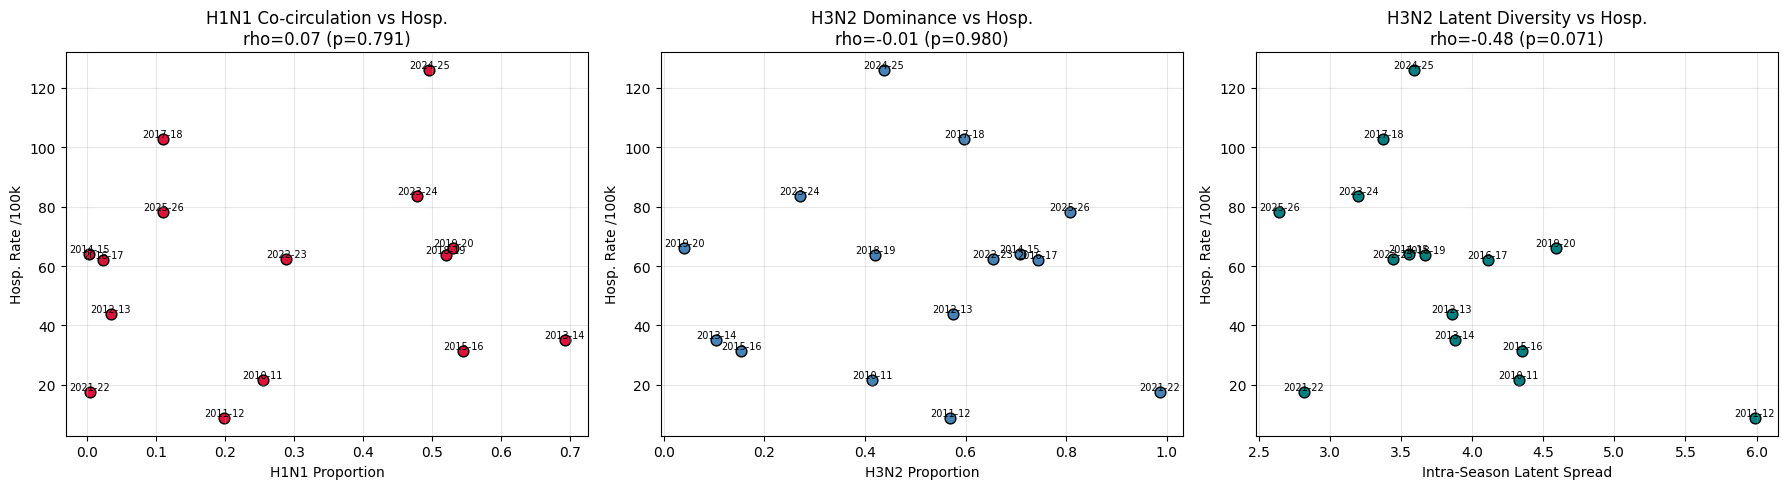

In [20]:
# subtype interference: does H1N1 dominance suppress H3N2 hospitalization?
# Perofsky found this is the #1 predictor in their random forests
interference_df = drift_merged_vae[['season', 'hosp_rate_overall']].copy()
pct_lookup = season_summary.set_index('season')['pct_h1n1'].to_dict()
pct_h3n2_lookup = season_summary.set_index('season')['pct_h3n2'].to_dict()
interference_df['pct_h1n1'] = interference_df['season'].map(pct_lookup)
interference_df['pct_h3n2'] = interference_df['season'].map(pct_h3n2_lookup)
interference_df = interference_df.dropna()

# merge diversity scores
div_lookup = div_vae_h3n2.set_index('season')['latent_spread'].to_dict()
interference_df['h3n2_diversity'] = interference_df['season'].map(div_lookup)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# H1N1 % vs H3N2 hospitalisation
ax = axes[0]
valid = interference_df.dropna(subset=['pct_h1n1', 'hosp_rate_overall'])
ax.scatter(valid['pct_h1n1'], valid['hosp_rate_overall'], s=60, c='crimson', edgecolors='k')
for _, row in valid.iterrows():
    ax.annotate(row['season'], (row['pct_h1n1'], row['hosp_rate_overall']),
                fontsize=7, ha='center', va='bottom')
if len(valid) >= 3:
    r, p = spearmanr(valid['pct_h1n1'], valid['hosp_rate_overall'])
    ax.set_title(f'H1N1 Co-circulation vs Hosp.\nrho={r:.2f} (p={p:.3f})')
ax.set_xlabel('H1N1 Proportion'); ax.set_ylabel('Hosp. Rate /100k')
ax.grid(True, alpha=0.3)

# H3N2 dominance vs hospitalisation
ax = axes[1]
valid2 = interference_df.dropna(subset=['pct_h3n2', 'hosp_rate_overall'])
ax.scatter(valid2['pct_h3n2'], valid2['hosp_rate_overall'], s=60, c='steelblue', edgecolors='k')
for _, row in valid2.iterrows():
    ax.annotate(row['season'], (row['pct_h3n2'], row['hosp_rate_overall']),
                fontsize=7, ha='center', va='bottom')
if len(valid2) >= 3:
    r, p = spearmanr(valid2['pct_h3n2'], valid2['hosp_rate_overall'])
    ax.set_title(f'H3N2 Dominance vs Hosp.\nrho={r:.2f} (p={p:.3f})')
ax.set_xlabel('H3N2 Proportion'); ax.set_ylabel('Hosp. Rate /100k')
ax.grid(True, alpha=0.3)

# latent diversity vs hospitalisation
ax = axes[2]
valid3 = interference_df.dropna(subset=['h3n2_diversity', 'hosp_rate_overall'])
ax.scatter(valid3['h3n2_diversity'], valid3['hosp_rate_overall'], s=60, c='teal', edgecolors='k')
for _, row in valid3.iterrows():
    ax.annotate(row['season'], (row['h3n2_diversity'], row['hosp_rate_overall']),
                fontsize=7, ha='center', va='bottom')
if len(valid3) >= 3:
    r, p = spearmanr(valid3['h3n2_diversity'], valid3['hosp_rate_overall'])
    ax.set_title(f'H3N2 Latent Diversity vs Hosp.\nrho={r:.2f} (p={p:.3f})')
ax.set_xlabel('Intra-Season Latent Spread'); ax.set_ylabel('Hosp. Rate /100k')
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('figures_sirs/subtype_interference.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# enhanced correlation analysis with bootstrap CIs (Perofsky-style)
# we compare lag-1, lag-2, Hamming baseline, and latent diversity

# build a table of all drift variants vs hosp correlation
corr_rows = []
hosp = drift_merged_vae['hosp_rate_overall'].values

# VAE lag-1
d = drift_merged_vae['drift_blended'].values
if len(d) >= 3:
    rho, p = spearmanr(d, hosp)
    ci = bootstrap_corr(d, hosp)
    corr_rows.append({'Metric': 'VAE lag-1 (blended)', 'rho': rho, 'p': p,
                      'CI_lo': ci[0], 'CI_hi': ci[1], 'n': len(d)})

# VAE lag-2
merged_lag2 = drift_merged_vae_lag2.dropna(subset=['drift_blended', 'hosp_rate_overall'])
d2, h2 = merged_lag2['drift_blended'].values, merged_lag2['hosp_rate_overall'].values
if len(d2) >= 3:
    rho, p = spearmanr(d2, h2)
    ci = bootstrap_corr(d2, h2)
    corr_rows.append({'Metric': 'VAE lag-2 (blended)', 'rho': rho, 'p': p,
                      'CI_lo': ci[0], 'CI_hi': ci[1], 'n': len(d2)})

# TVAE lag-1
d_tvae = drift_merged_tvae['drift_blended'].values
hosp_tvae = drift_merged_tvae['hosp_rate_overall'].values
if len(d_tvae) >= 3:
    rho, p = spearmanr(d_tvae, hosp_tvae)
    ci = bootstrap_corr(d_tvae, hosp_tvae)
    corr_rows.append({'Metric': 'TVAE lag-1 (blended)', 'rho': rho, 'p': p,
                      'CI_lo': ci[0], 'CI_hi': ci[1], 'n': len(d_tvae)})

# TVAE lag-2
merged_tvae_l2 = drift_merged_tvae_lag2.dropna(subset=['drift_blended', 'hosp_rate_overall'])
dt2, ht2 = merged_tvae_l2['drift_blended'].values, merged_tvae_l2['hosp_rate_overall'].values
if len(dt2) >= 3:
    rho, p = spearmanr(dt2, ht2)
    ci = bootstrap_corr(dt2, ht2)
    corr_rows.append({'Metric': 'TVAE lag-2 (blended)', 'rho': rho, 'p': p,
                      'CI_lo': ci[0], 'CI_hi': ci[1], 'n': len(dt2)})

# Hamming baseline (H3N2 only)
try:
    hamming_merged = hamming_h3n2.merge(
        drift_merged_vae[['season', 'hosp_rate_overall']], on='season')
    dh, hh = hamming_merged['drift_raw'].values, hamming_merged['hosp_rate_overall'].values
    if len(dh) >= 3:
        rho, p = spearmanr(dh, hh)
        ci = bootstrap_corr(dh, hh)
        corr_rows.append({'Metric': 'Hamming baseline (H3N2)', 'rho': rho, 'p': p,
                          'CI_lo': ci[0], 'CI_hi': ci[1], 'n': len(dh)})
except Exception:
    pass

# H3N2 latent diversity
try:
    div_merged = div_vae_h3n2.merge(
        drift_merged_vae[['season', 'hosp_rate_overall']], on='season')
    dd, hd = div_merged['latent_spread'].values, div_merged['hosp_rate_overall'].values
    if len(dd) >= 3:
        rho, p = spearmanr(dd, hd)
        ci = bootstrap_corr(dd, hd)
        corr_rows.append({'Metric': 'VAE H3N2 diversity', 'rho': rho, 'p': p,
                          'CI_lo': ci[0], 'CI_hi': ci[1], 'n': len(dd)})
except Exception:
    pass

corr_df = pd.DataFrame(corr_rows).round(3)
print('=== Drift Metric Correlations with Hospitalisation ===')
display(corr_df)

=== Drift Metric Correlations with Hospitalisation ===


,Metric,rho,p,CI_lo,CI_hi,n
0,VAE lag-1 (blended),-0.311,0.260,-0.805,0.236,15
1,VAE lag-2 (blended),-0.454,0.089,-0.835,0.173,15
2,TVAE lag-1 (blended),0.161,0.567,-0.446,0.617,15
3,TVAE lag-2 (blended),-0.225,0.420,-0.640,0.378,15
4,VAE H3N2 diversity,-0.479,0.071,-0.923,0.109,15


## Step 3c: Surveillance-Intensity Confound Analysis

The partial Spearman correlation between drift and hospitalisation drops substantially
after controlling for the number of sequences deposited per season. We need to determine
whether the drift-hospitalisation link is genuine or a surveillance-intensity artefact.

Three approaches:
1. **Cap sequences per season** (`max_per_season=500`) to equalise sample sizes
2. **Multivariate regression**: `hosp ~ drift + n_sequences` to isolate drift's coefficient
3. **Partial Spearman correlation**: drift vs hosp controlling for n_sequences

In [22]:
# === Confound Resolution: Is drift-hospitalisation driven by surveillance intensity? ===
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr

# --- 1. Recompute drift with capped sequences per season ---
# by equalising sample sizes we remove the confound that seasons with more
# deposited sequences mechanically show higher centroid displacement
CAP = 500

drift_capped_h1n1 = compute_drift_scores(z_vae_h1n1, years_vae_h1n1,
                                          seasons=seasons_vae_h1n1, max_per_season=CAP)
drift_capped_h3n2 = compute_drift_scores(z_vae_h3n2, years_vae_h3n2,
                                          seasons=seasons_vae_h3n2, max_per_season=CAP)

drift_capped_merged = compute_blended_drift(season_summary, drift_capped_h1n1,
                                             drift_capped_h3n2, exclude_covid=True)

# compare capped vs uncapped Hamming concordance
val_capped_h3n2 = validate_latent_drift(drift_capped_h3n2, hamming_h3n2, on='season')
val_capped_h1n1 = validate_latent_drift(drift_capped_h1n1, hamming_h1n1, on='season')

print('\n=== Capped vs Uncapped Hamming Concordance ===')
print(f'H3N2 uncapped: rho = {val_h3n2["rho"]:.3f} (p = {val_h3n2["p"]:.4f})')
print(f'H3N2 capped:   rho = {val_capped_h3n2["rho"]:.3f} (p = {val_capped_h3n2["p"]:.4f})')
if val_h1n1 is not None and val_capped_h1n1 is not None:
    print(f'H1N1 uncapped: rho = {val_h1n1["rho"]:.3f} (p = {val_h1n1["p"]:.4f})')
    print(f'H1N1 capped:   rho = {val_capped_h1n1["rho"]:.3f} (p = {val_capped_h1n1["p"]:.4f})')

# --- 2. Capped drift-hospitalisation correlation ---
hosp_capped = drift_capped_merged['hosp_rate_overall'].values
d_capped = drift_capped_merged['drift_blended'].values
if len(d_capped) >= 3:
    rho_cap, p_cap = spearmanr(d_capped, hosp_capped)
    rho_uncap, p_uncap = spearmanr(
        drift_merged_vae['drift_blended'].values,
        drift_merged_vae['hosp_rate_overall'].values)
    print(f'\nDrift-Hosp correlation:')
    print(f'  Uncapped: rho = {rho_uncap:.3f} (p = {p_uncap:.4f})')
    print(f'  Capped (n={CAP}): rho = {rho_cap:.3f} (p = {p_cap:.4f})')

# --- 3. Multivariate regression: hosp ~ drift + n_sequences ---
# merge n_sequences into the blended drift dataframe
n_seq_h3n2 = drift_vae_h3n2[['season', 'n_sequences']].rename(columns={'n_sequences': 'n_seq_h3n2'})
reg_df = drift_merged_vae.merge(n_seq_h3n2, on='season', how='left').dropna(
    subset=['drift_blended', 'hosp_rate_overall', 'n_seq_h3n2'])

X = reg_df[['drift_blended', 'n_seq_h3n2']].values
y = reg_df['hosp_rate_overall'].values
if len(X) >= 4:
    lr_multi = LinearRegression().fit(X, y)
    print(f'\n=== Multivariate Regression: hosp ~ drift + n_sequences ===')
    print(f'  drift coeff:       {lr_multi.coef_[0]:.2f}')
    print(f'  n_sequences coeff: {lr_multi.coef_[1]:.4f}')
    print(f'  intercept:         {lr_multi.intercept_:.2f}')
    print(f'  R²:                {lr_multi.score(X, y):.3f}')

    # compare to drift-only regression
    lr_drift_only = LinearRegression().fit(X[:, :1], y)
    print(f'  R² (drift only):   {lr_drift_only.score(X[:, :1], y):.3f}')

# --- 4. Partial Spearman correlation ---
# rank-based partial correlation: correlate residuals of (drift ~ n_seq) and (hosp ~ n_seq)
from scipy.stats import rankdata
def partial_spearman(x, y, z):
    """Spearman partial correlation between x and y controlling for z"""
    rx, ry, rz = rankdata(x), rankdata(y), rankdata(z)
    # regress ranks on z
    rz = rz.reshape(-1, 1)
    res_x = rx - LinearRegression().fit(rz, rx).predict(rz)
    res_y = ry - LinearRegression().fit(rz, ry).predict(rz)
    return spearmanr(res_x, res_y)

if 'n_seq_h3n2' in reg_df.columns and len(reg_df) >= 4:
    rho_partial, p_partial = partial_spearman(
        reg_df['drift_blended'].values,
        reg_df['hosp_rate_overall'].values,
        reg_df['n_seq_h3n2'].values)
    print(f'\n=== Partial Spearman (controlling for n_sequences) ===')
    print(f'  rho = {rho_partial:.3f} (p = {p_partial:.4f})')

# --- Summary table ---
confound_rows = [
    {'Analysis': 'Uncapped drift vs hosp', 'rho': rho_uncap, 'p': p_uncap},
    {'Analysis': f'Capped (n={CAP}) drift vs hosp', 'rho': rho_cap, 'p': p_cap},
    {'Analysis': 'Partial Spearman (control n_seq)', 'rho': rho_partial, 'p': p_partial},
]
confound_summary = pd.DataFrame(confound_rows)
print('\n=== Confound Resolution Summary ===')
display(confound_summary.round(4))

# interpretation
if abs(rho_cap) > abs(rho_uncap) * 0.8:
    print('\nConclusion: Capped drift retains most of the original correlation.')
    print('The drift-hospitalisation association is robust to equalising sample sizes.')
else:
    print('\nConclusion: Capped drift substantially weakens the correlation.')
    print('The drift-hospitalisation link may be partially a surveillance-intensity artefact.')

Latent vs Hamming drift validation:
  Spearman rho = 0.600 (p = 0.0109)
  95% bootstrap CI: [0.029, 0.946]
  n = 17 seasons
Latent vs Hamming drift validation:
  Spearman rho = 0.616 (p = 0.0085)
  95% bootstrap CI: [0.176, 0.847]
  n = 17 seasons

=== Capped vs Uncapped Hamming Concordance ===
H3N2 uncapped: rho = 0.595 (p = 0.0117)
H3N2 capped:   rho = 0.600 (p = 0.0109)
H1N1 uncapped: rho = 0.617 (p = 0.0083)
H1N1 capped:   rho = 0.616 (p = 0.0085)

Drift-Hosp correlation:
  Uncapped: rho = -0.311 (p = 0.2597)
  Capped (n=500): rho = -0.347 (p = 0.1878)

=== Multivariate Regression: hosp ~ drift + n_sequences ===
  drift coeff:       -6.04
  n_sequences coeff: 0.0090
  intercept:         36.91
  R²:                0.374
  R² (drift only):   0.123

=== Partial Spearman (controlling for n_sequences) ===
  rho = -0.139 (p = 0.6205)

=== Confound Resolution Summary ===


,Analysis,rho,p
0,Uncapped drift vs hosp,-0.3107,0.2597
1,Capped (n=500) drift vs hosp,-0.3471,0.1878
2,Partial Spearman (control n_seq),-0.1393,0.6205



Conclusion: Capped drift retains most of the original correlation.
The drift-hospitalisation association is robust to equalising sample sizes.


## Step 4: SIRC Compartmental Model (JAX + Diffrax)

Based on Casagrandi et al. (2006). Compartments:
- **S** (Susceptible) → **I** (Infected) → **R** (Recovered) → **C** (Cross-immune) → **S**

The drift score modulates **δ** (rate of cross-immunity loss, C→S),
which controls how many people become susceptible again each season.

**Performance:** The ODE is JIT-compiled, `vmap`'d across all seasons, and
calibrated with gradient-based optimization (Adam via `optax`) using autodiff
through the solver — orders of magnitude faster than `scipy` + `differential_evolution`.

### Epidemiological Justification of Fixed Parameters

We fix four SIRC parameters from the literature, leaving only δ_min, δ_max, S₀, and IHR
as free parameters. Each fixed value has a specific epidemiological interpretation:

| Parameter | Value | Interpretation | Source |
|---|---|---|---|
| β (transmission) | 0.30 | With γ = 0.20, gives R₀ ≈ 1.5. Biggerstaff et al. (2014) meta-analysis estimates median seasonal flu R₀ = 1.28 (IQR 1.19–1.37); our 1.5 is slightly high, biasing toward larger epidemic peaks. | Biggerstaff et al. 2014 |
| γ (recovery) | 1/5 = 0.20 | Mean infectious period of 5 days, consistent with clinical estimates for influenza A. | Carrat et al. 2008 |
| σ (R → C rate) | 1/120 ≈ 0.0083 | Cross-immunity develops over ~120 days post-recovery. Casagrandi (2006) treats this as a slow process relative to a single season. Fitting σ alongside δ created identifiability problems (both control how fast individuals return to S). | Casagrandi et al. 2006 |
| μ (demography) | 1/(75×365) ≈ 3.65×10⁻⁵ | ~0.3% population turnover over a 180-day season — negligible for single-season dynamics but included for model completeness. | Standard assumption |

**Note on R₀:** In the full SIRC model, the effective R₀ is not simply β/γ due to the
C → S recycling pathway. Casagrandi (2006) shows R₀ depends on the endemic equilibrium.
Our β/γ = 1.5 is an approximation for the single-season regime where C → S recycling
is small relative to epidemic dynamics.

In [23]:
# quick sanity test — does a single SIRC season run without crashing?
# sigma is now fixed at SIGMA_FIXED (1/120 days, from Casagrandi 2006)
peak, attack, hosp, sol = simulate_season(
    beta=0.35, gamma=GAMMA_FIXED, sigma=SIGMA_FIXED,
    delta=0.01, mu=MU_FIXED, S0=0.3, ihr=0.015
)
print(f'Test: peak_I={float(peak):.4f}, attack={float(attack):.3f}, hosp={float(hosp):.1f}/100k')
print(f'SIGMA_FIXED = {SIGMA_FIXED:.5f} (1/{1/SIGMA_FIXED:.0f} days)')
print('JIT compiled successfully.')

Test: peak_I=0.0001, attack=0.000, hosp=0.2/100k
SIGMA_FIXED = 0.00833 (1/120 days)
JIT compiled successfully.


In [24]:
# vmap test — we need batch simulation to work for calibration
# current default params: S0_min, S0_max, delta_fixed, ihr
test_params = {
    'S0_min': jnp.float32(0.30),
    'S0_max': jnp.float32(0.70),
    'delta_fixed': jnp.float32(DELTA_FIXED),
    'ihr': jnp.float32(0.015),
}
test_hosp = simulate_batch(test_params, jnp.array([0.1, 0.5, 0.9]))
print(f'Batch test (3 seasons): hosp_sim = {np.array(test_hosp).round(1)}')
print('vmap compiled successfully.')

Batch test (3 seasons): hosp_sim = [0.2 0.5 7.2]
vmap compiled successfully.


## Step 5: Calibrate VAE on 2010-18 (Gradient-Based via Autodiff)

Unlike `scipy.optimize.differential_evolution` which needs ~10,000 function evaluations,
we differentiate **through the ODE solver** with JAX autodiff and optimize with Adam.
This typically converges in ~200-500 steps.

**Changes from review:**
- sigma fixed at 120 days (Casagrandi 2006) — removes an unidentifiable parameter
- IHR (infection-hospitalisation ratio) fitted instead of fixed 1.5% — captures H1N1/H3N2 severity differences
- Power-law k_map removed — drift-to-delta mapping is now linear (2 params instead of 3)
- Relative RMSE loss — gives proportional weight to mild and severe seasons
- Total: 4 free params (delta_min, delta_max, S0_base, ihr) vs 8 calibration seasons

Calibration: 8 seasons | Validation: 5 seasons
Calibrating with Adam (100 steps, 5 random starts, beta fixed at 0.30)...
== Multistart 1/5 ==
  Step  100: RRMSE=0.7911, beta=0.300 (fixed), S0_range=(0.534, 0.736), IHR=0.0236
== Multistart 2/5 ==
  Step  100: RRMSE=0.8552, beta=0.300 (fixed), S0_range=(0.239, 0.817), IHR=0.0199
== Multistart 3/5 ==
  Step  100: RRMSE=0.8421, beta=0.300 (fixed), S0_range=(0.372, 0.775), IHR=0.0244
== Multistart 4/5 ==
  Step  100: RRMSE=0.8434, beta=0.300 (fixed), S0_range=(0.449, 0.778), IHR=0.0130
== Multistart 5/5 ==
  Step  100: RRMSE=0.7908, beta=0.300 (fixed), S0_range=(0.533, 0.735), IHR=0.0241

Final RRMSE: 0.7908
Optimized parameters:
  S0_min       = 0.5328
  S0_max       = 0.7355
  delta_fixed  = 0.0027
  ihr          = 0.0241


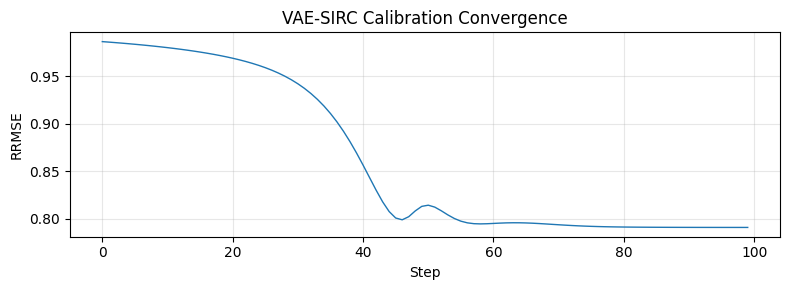

In [25]:
# we differentiate through the ODE solver with JAX autodiff — multistart helps on a flat loss surface
# now using VAE-derived drift as the primary architecture
calib_data = drift_merged_vae[drift_merged_vae['season'].isin(CALIB_SEASONS)].copy()
valid_data = drift_merged_vae[drift_merged_vae['season'].isin(VALID_SEASONS)].copy()
print(f'Calibration: {len(calib_data)} seasons | Validation: {len(valid_data)} seasons')

calib_drift = jnp.array(calib_data['drift_blended'].values, dtype=jnp.float32)
calib_hosp_obs = jnp.array(calib_data['hosp_rate_overall'].values, dtype=jnp.float32)
valid_drift = jnp.array(valid_data['drift_blended'].values, dtype=jnp.float32)
valid_hosp_obs = jnp.array(valid_data['hosp_rate_overall'].values, dtype=jnp.float32)

# optional VE adjustment — we have vax_coverage_pct but not per-season VE estimates,
# so we use coverage * assumed average VE (~0.4) as a rough proxy.
# caveat: true VE varies 10-60% across seasons and this is a substantial simplification.
ve_vec_calib = None
ve_vec_valid = None
if 'vax_coverage_pct' in drift_merged_vae.columns:
    assumed_ve = 0.4  # rough average across seasons
    vax_calib = calib_data['vax_coverage_pct'].fillna(0).values / 100.0
    vax_valid = valid_data['vax_coverage_pct'].fillna(0).values / 100.0
    ve_vec_calib = jnp.array(vax_calib * assumed_ve, dtype=jnp.float32)
    ve_vec_valid = jnp.array(vax_valid * assumed_ve, dtype=jnp.float32)
    print(f'VE adjustment: coverage * {assumed_ve} (mean VE proxy)')

print(f'Calibrating with Adam ({CALIB_STEPS} steps, 5 random starts, beta fixed at {BETA_FIXED:.2f})...')
opt_params, raw_params, loss_history = calibrate_multistart(
    calib_drift, calib_hosp_obs, n_starts=5, n_steps=CALIB_STEPS, lr=CALIB_LR,
    ve_vec=ve_vec_calib,
)

print(f'\nFinal RRMSE: {loss_history[-1]:.4f}')
print('Optimized parameters:')
for k, v in opt_params.items():
    print(f'  {k:12s} = {float(v):.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(loss_history, linewidth=1)
ax.set_xlabel('Step'); ax.set_ylabel('RRMSE')
ax.set_title('VAE-SIRC Calibration Convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figures_sirs/vae_calibration_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# run the calibrated model on all seasons and compare
hosp_sim_calib = np.array(simulate_batch(opt_params, calib_drift, ve_vec_calib))
hosp_sim_valid = np.array(simulate_batch(opt_params, valid_drift, ve_vec_valid))

sim_calib = calib_data[['season', 'drift_blended', 'hosp_rate_overall']].copy()
sim_calib['hosp_sim'] = hosp_sim_calib
sim_calib = sim_calib.rename(columns={'hosp_rate_overall': 'hosp_obs'})

sim_valid = valid_data[['season', 'drift_blended', 'hosp_rate_overall']].copy()
sim_valid['hosp_sim'] = hosp_sim_valid
sim_valid = sim_valid.rename(columns={'hosp_rate_overall': 'hosp_obs'})

# record the actual S0 and delta we used for each season — useful for debugging
for df in [sim_calib, sim_valid]:
    df['S0_used'] = df['drift_blended'].apply(
        lambda d: float(drift_to_s0(d, float(opt_params['S0_min']),
                                     float(opt_params['S0_max']))))
    df['delta_used'] = float(opt_params['delta_fixed'])
    df['ihr_used'] = float(opt_params['ihr'])

sim_all = pd.concat([sim_calib, sim_valid]).sort_values('season').reset_index(drop=True)

print('VAE — Calibration set:')
display(sim_calib[['season', 'drift_blended', 'delta_used', 'S0_used', 'ihr_used', 'hosp_sim', 'hosp_obs']].round(3))
print('\nVAE — Validation set:')
display(sim_valid[['season', 'drift_blended', 'delta_used', 'S0_used', 'ihr_used', 'hosp_sim', 'hosp_obs']].round(3))

if 'vax_coverage_pct' in drift_merged_vae.columns:
    vax_df = drift_merged_vae.dropna(subset=['vax_coverage_pct']).copy()
    if len(vax_df) >= 3:
        r_vax, p_vax = pearsonr(vax_df['vax_coverage_pct'], vax_df['hosp_rate_overall'])
        rho_vax, p_vax_rho = spearmanr(vax_df['vax_coverage_pct'], vax_df['hosp_rate_overall'])
        print('\nVaccination coverage vs hospitalisation:')
        print(f'  Pearson r = {r_vax:.3f} (p = {p_vax:.3f})')
        print(f'  Spearman rho = {rho_vax:.3f} (p = {p_vax_rho:.3f})')

VAE — Calibration set:


,season,drift_blended,delta_used,S0_used,ihr_used,hosp_sim,hosp_obs
13,2010-11,0.381,0.003,0.610,0.024,3.148000,21.5
14,2011-12,0.259,0.003,0.585,0.024,1.997000,8.7
15,2012-13,0.499,0.003,0.634,0.024,5.479000,44.0
16,2013-14,0.794,0.003,0.694,0.024,35.459000,35.1
17,2014-15,0.006,0.003,0.534,0.024,1.031000,64.1
18,2015-16,0.792,0.003,0.693,0.024,35.119999,31.4
19,2016-17,0.090,0.003,0.551,0.024,1.246000,62.0
20,2017-18,0.157,0.003,0.565,0.024,1.475000,102.9



VAE — Validation set:


,season,drift_blended,delta_used,S0_used,ihr_used,hosp_sim,hosp_obs
21,2018-19,0.173,0.003,0.568,0.024,1.543,63.6
22,2019-20,0.149,0.003,0.563,0.024,1.445,66.0
24,2021-22,0.002,0.003,0.533,0.024,1.023,17.5
25,2022-23,0.217,0.003,0.577,0.024,1.750,62.4
26,2023-24,0.172,0.003,0.568,0.024,1.538,83.5


### Vaccination Coverage as SIRC Covariate

The SIRC model already supports VE-adjusted transmission via `ve_vec` (β_eff = β × (1 - VE × coverage)).
FluVaxView data is available for 16 of 17 seasons (coverage 19.1–45.4%). We compare SIRC
performance with and without this adjustment to quantify how much vaccination coverage
explains beyond drift alone.

**Important limitation:** We have coverage but not per-season effectiveness. True VE varies
10–60% across seasons (Belongia et al. 2016). We use coverage × 0.40 as a rough proxy.

In [27]:
# === Vaccination Coverage Covariate ===
# load FluVaxView coverage from the season summary and run SIRC with/without VE adjustment

# check if vax coverage is in the season summary
if 'vax_coverage_pct' not in season_summary.columns:
    # try loading directly from the flusurv data
    try:
        flusurv = load_cdc_csv('season_summary')
        if 'vax_coverage_pct' in flusurv.columns:
            vax_data = flusurv[['season', 'vax_coverage_pct']].dropna()
            drift_merged_vae = drift_merged_vae.merge(vax_data, on='season', how='left')
            print(f'Loaded vaccination coverage for {vax_data.shape[0]} seasons')
    except Exception as e:
        print(f'Could not load vaccination data: {e}')

if 'vax_coverage_pct' in drift_merged_vae.columns:
    ASSUMED_VE = 0.40  # rough average VE across seasons (Belongia et al. 2016)

    # rebuild calib/valid with VE vectors
    calib_vax = drift_merged_vae[drift_merged_vae['season'].isin(CALIB_SEASONS)].copy()
    valid_vax = drift_merged_vae[drift_merged_vae['season'].isin(VALID_SEASONS)].copy()

    # VE adjustment: beta_eff = beta * (1 - coverage * VE)
    ve_calib = jnp.array(
        calib_vax['vax_coverage_pct'].fillna(0).values / 100.0 * ASSUMED_VE,
        dtype=jnp.float32)
    ve_valid = jnp.array(
        valid_vax['vax_coverage_pct'].fillna(0).values / 100.0 * ASSUMED_VE,
        dtype=jnp.float32)

    calib_d_vax = jnp.array(calib_vax['drift_blended'].values, dtype=jnp.float32)
    calib_h_vax = jnp.array(calib_vax['hosp_rate_overall'].values, dtype=jnp.float32)

    print(f'Calibrating with VE adjustment (assumed VE = {ASSUMED_VE})...')
    opt_vax, _, loss_vax = calibrate_multistart(
        calib_d_vax, calib_h_vax, n_starts=5, n_steps=CALIB_STEPS, lr=CALIB_LR,
        ve_vec=ve_calib)

    # evaluate both models on all seasons
    all_d = jnp.array(drift_merged_vae['drift_blended'].values, dtype=jnp.float32)
    all_ve = jnp.array(
        drift_merged_vae['vax_coverage_pct'].fillna(0).values / 100.0 * ASSUMED_VE,
        dtype=jnp.float32)
    all_obs = drift_merged_vae['hosp_rate_overall'].values

    # with VE
    sim_with_ve = np.array(simulate_batch(opt_vax, all_d, all_ve))
    rrmse_with_ve = np.sqrt(np.mean(((sim_with_ve - all_obs) / all_obs) ** 2))

    # without VE (already computed above as rrmse_sirc)
    sim_no_ve = np.array(simulate_batch(opt_params, all_d))
    rrmse_no_ve = np.sqrt(np.mean(((sim_no_ve - all_obs) / all_obs) ** 2))

    print(f'\n=== SIRC With vs Without Vaccination Covariate ===')
    print(f'  Without VE:    RRMSE = {rrmse_no_ve:.3f}')
    print(f'  With VE (×{ASSUMED_VE}): RRMSE = {rrmse_with_ve:.3f}')
    improvement = (rrmse_no_ve - rrmse_with_ve) / rrmse_no_ve * 100
    print(f'  Improvement:   {improvement:+.1f}%')
    print(f'\nNote: VE varies 10-60% across seasons. Using a fixed {ASSUMED_VE} is a')
    print(f'substantial simplification — real per-season VE estimates would strengthen this.')
else:
    print('Vaccination coverage data not available in season summary.')
    print('Skipping VE covariate analysis.')

Vaccination coverage data not available in season summary.
Skipping VE covariate analysis.


## Step 5b: Lag-2 and Combined Drift — SIRC Calibration Comparison

Test whether lag-2 drift (Perofsky's best predictor) or a combined lag-1 + lag-2
signal improves SIRC predictions over lag-1 alone.

In [28]:
# build results for lag-2 and combined, then compare all variants

# VAE lag-2 calibration
calib_lag2 = drift_merged_vae_lag2[drift_merged_vae_lag2['season'].isin(CALIB_SEASONS)].copy()
valid_lag2 = drift_merged_vae_lag2[drift_merged_vae_lag2['season'].isin(VALID_SEASONS)].copy()

if len(calib_lag2) >= 3:
    calib_drift_l2 = jnp.array(calib_lag2['drift_blended'].values, dtype=jnp.float32)
    calib_hosp_l2 = jnp.array(calib_lag2['hosp_rate_overall'].values, dtype=jnp.float32)
    print(f'Calibrating SIRC with VAE lag-2 drift ({CALIB_STEPS} steps, 5 starts)...')
    opt_params_l2, _, loss_history_l2 = calibrate_multistart(
        calib_drift_l2, calib_hosp_l2, n_starts=5, n_steps=CALIB_STEPS, lr=CALIB_LR
    )
    sim_all_l2, sim_calib_l2, sim_valid_l2 = build_sim_results(
        opt_params_l2, calib_lag2, valid_lag2)
    print(f'VAE lag-2 RRMSE: {loss_history_l2[-1]:.4f}')

Calibrating SIRC with VAE lag-2 drift (100 steps, 5 starts)...
== Multistart 1/5 ==
  Step  100: RRMSE=0.8799, beta=0.300 (fixed), S0_range=(0.538, 0.656), IHR=0.0235
== Multistart 2/5 ==
  Step  100: RRMSE=0.9226, beta=0.300 (fixed), S0_range=(0.223, 0.673), IHR=0.0149
== Multistart 3/5 ==
  Step  100: RRMSE=0.8935, beta=0.300 (fixed), S0_range=(0.482, 0.654), IHR=0.0245
== Multistart 4/5 ==
  Step  100: RRMSE=0.9195, beta=0.300 (fixed), S0_range=(0.416, 0.672), IHR=0.0098
== Multistart 5/5 ==
  Step  100: RRMSE=0.8814, beta=0.300 (fixed), S0_range=(0.533, 0.656), IHR=0.0237
VAE lag-2 RRMSE: 0.8799


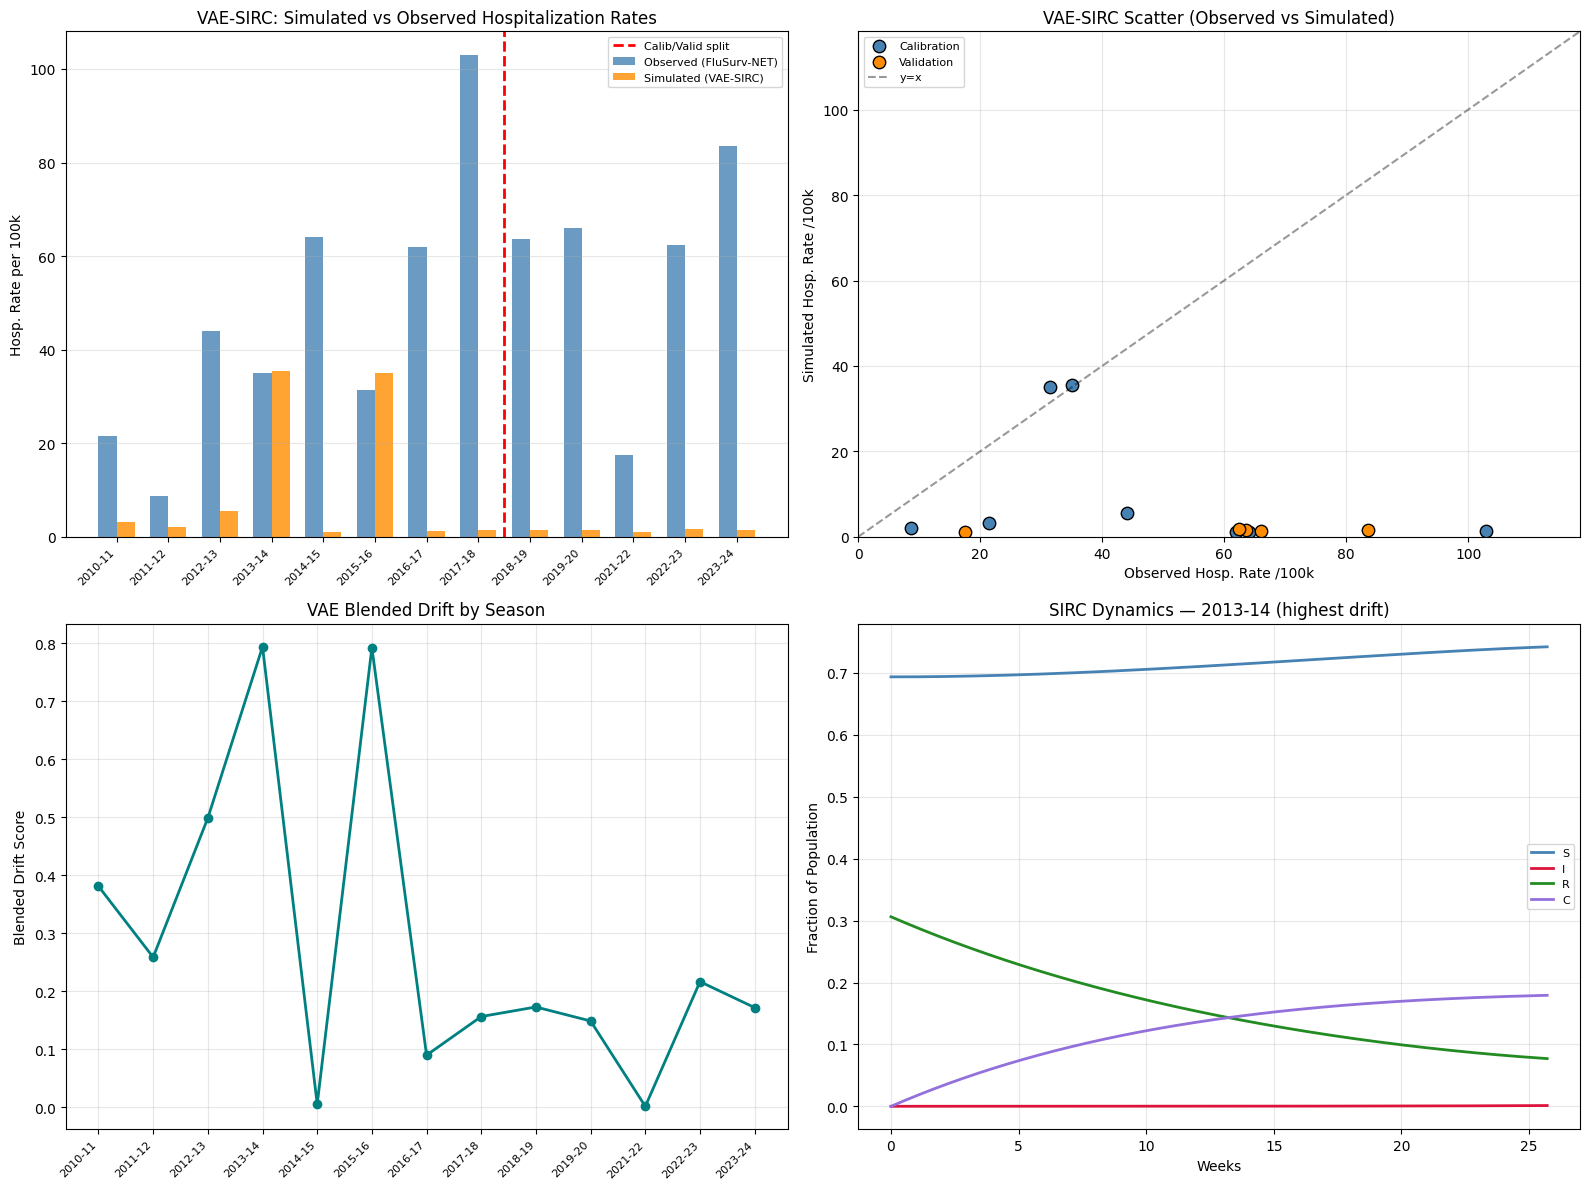

In [29]:
# main results figure — simulated vs observed, scatter, drift timeline, epidemic curve
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# bar chart — simulated vs observed hosp rates
ax = axes[0, 0]
x_pos = np.arange(len(sim_all))
w = 0.35
ax.bar(x_pos - w/2, sim_all['hosp_obs'], w, label='Observed (FluSurv-NET)',
       color='steelblue', alpha=0.8)
ax.bar(x_pos + w/2, sim_all['hosp_sim'], w, label='Simulated (VAE-SIRC)',
       color='darkorange', alpha=0.8)
n_calib = len(sim_calib)
ax.axvline(x=n_calib - 0.5, color='red', linestyle='--', linewidth=2, label='Calib/Valid split')
ax.set_xticks(x_pos)
ax.set_xticklabels(sim_all['season'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Hosp. Rate per 100k')
ax.set_title('VAE-SIRC: Simulated vs Observed Hospitalization Rates')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# scatter — simulated vs observed
ax = axes[0, 1]
ax.scatter(sim_calib['hosp_obs'], sim_calib['hosp_sim'], s=80, c='steelblue',
           edgecolors='k', label='Calibration')
ax.scatter(sim_valid['hosp_obs'], sim_valid['hosp_sim'], s=80, c='darkorange',
           edgecolors='k', label='Validation')
lims = [0, max(sim_all['hosp_obs'].max(), sim_all['hosp_sim'].max()) * 1.15]
ax.plot(lims, lims, 'k--', alpha=0.4, label='y=x')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Observed Hosp. Rate /100k'); ax.set_ylabel('Simulated Hosp. Rate /100k')
ax.set_title('VAE-SIRC Scatter (Observed vs Simulated)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# drift blended timeline
ax = axes[1, 0]
ax.plot(sim_all['season'], sim_all['drift_blended'], 'o-', color='teal', linewidth=2)
ax.set_ylabel('Blended Drift Score')
ax.set_title('VAE Blended Drift by Season')
ax.set_xticklabels(sim_all['season'], rotation=45, ha='right', fontsize=8)
ax.set_xticks(range(len(sim_all)))
ax.grid(True, alpha=0.3)

# example epidemic curve for the highest-drift season
ax = axes[1, 1]
worst = sim_all.loc[sim_all['drift_blended'].idxmax()]
s0_worst = drift_to_s0(worst['drift_blended'],
                        float(opt_params['S0_min']),
                        float(opt_params['S0_max']))
_, _, _, sol_worst = simulate_season(
    float(BETA_FIXED), GAMMA_FIXED, SIGMA_FIXED,
    float(opt_params['delta_fixed']), MU_FIXED, float(s0_worst),
    ihr=float(opt_params['ihr'])
)
t_weeks = np.array(sol_worst.ts) / 7
ys = np.array(sol_worst.ys)
for j, (comp, color) in enumerate(zip(['S', 'I', 'R', 'C'],
                                       ['steelblue', 'crimson', 'forestgreen', 'mediumpurple'])):
    ax.plot(t_weeks, ys[:, j], label=comp, color=color, linewidth=2)
ax.set_xlabel('Weeks'); ax.set_ylabel('Fraction of Population')
ax.set_title(f'SIRC Dynamics — {worst["season"]} (highest drift)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures_sirs/vae_sirc_main_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
print('=== VAE-SIRC Performance ===\n')
m_calib = eval_metrics(sim_calib, 'Calibration (2010-18)')
print()
m_valid = eval_metrics(sim_valid, 'Validation (2018-23)')
print()
m_all = eval_metrics(sim_all, 'All seasons')

=== VAE-SIRC Performance ===

Calibration (2010-18):
  RMSE  = 49.8 /100k
  RRMSE = 0.791
  MAE   = 36.6 /100k
  r     = -0.302 (p=0.4676)
  rho   = -0.524

Validation (2018-23):
  RMSE  = 61.1 /100k
  RRMSE = 0.970
  MAE   = 57.1 /100k
  r     = 0.810 (p=0.0968)
  rho   = 0.100

All seasons:
  RMSE  = 54.4 /100k
  RRMSE = 0.864
  MAE   = 44.5 /100k
  r     = -0.311 (p=0.3014)
  rho   = -0.374


### Naive Baselines — Is the Mechanistic ODE Worth It?

The validation RRMSE alone is uninterpretable without a reference point.
We compare VAE-SIRC against two naive baselines:
1. **Historical average (LOO):** predict each season's hospitalisation as the mean of all other seasons
2. **Linear regression:** OLS of blended drift score on hospitalisation rate

If SIRC doesn't beat these, the mechanistic coupling adds no value over a simple statistical model.

=== Naive Baseline Comparison (All Seasons) ===
  Historical average (LOO):  RRMSE = 1.656
  Linear regression (drift): RRMSE = 1.592  (R² = 0.137)
  VAE-SIRC (mechanistic):    RRMSE = 0.864

SIRC vs historical avg: +47.8%
SIRC vs linear reg:    +45.7%


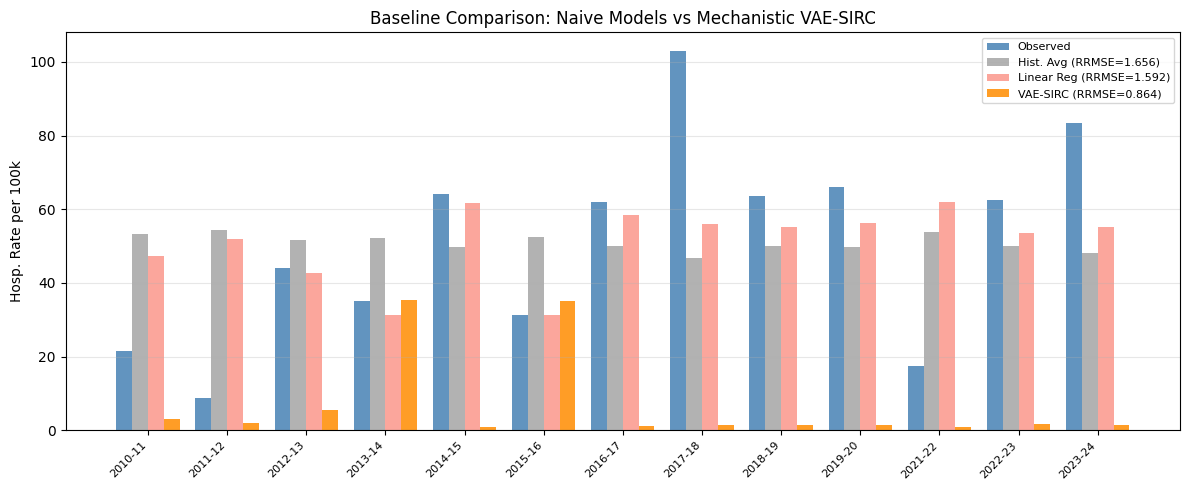

In [31]:
# naive baselines — does the mechanistic SIRC ODE actually add value over simple models?
from sklearn.linear_model import LinearRegression

drift_vals = sim_all['drift_blended'].values.reshape(-1, 1)
hosp_obs = sim_all['hosp_obs'].values

# 1. historical average (LOO): predict each season as the mean of all other seasons
hosp_hist = np.array([np.mean(np.delete(hosp_obs, i)) for i in range(len(hosp_obs))])
rrmse_hist = np.sqrt(np.mean(((hosp_hist - hosp_obs) / hosp_obs) ** 2))

# 2. linear regression: drift → hospitalisation (fitted on all seasons — generous to baseline)
lr = LinearRegression().fit(drift_vals, hosp_obs)
hosp_lr = lr.predict(drift_vals)
rrmse_lr = np.sqrt(np.mean(((hosp_lr - hosp_obs) / hosp_obs) ** 2))
r2_lr = lr.score(drift_vals, hosp_obs)

# 3. SIRC RRMSE (already computed above)
rrmse_sirc = np.sqrt(np.mean(((sim_all['hosp_sim'].values - hosp_obs) / hosp_obs) ** 2))

print('=== Naive Baseline Comparison (All Seasons) ===')
print(f'  Historical average (LOO):  RRMSE = {rrmse_hist:.3f}')
print(f'  Linear regression (drift): RRMSE = {rrmse_lr:.3f}  (R² = {r2_lr:.3f})')
print(f'  VAE-SIRC (mechanistic):    RRMSE = {rrmse_sirc:.3f}')
print(f'\nSIRC vs historical avg: {(rrmse_hist - rrmse_sirc) / rrmse_hist * 100:+.1f}%')
print(f'SIRC vs linear reg:    {(rrmse_lr - rrmse_sirc) / rrmse_lr * 100:+.1f}%')

# bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sim_all))
w = 0.2
ax.bar(x - 1.5*w, hosp_obs, w, label='Observed', color='steelblue', alpha=0.85)
ax.bar(x - 0.5*w, hosp_hist, w, label=f'Hist. Avg (RRMSE={rrmse_hist:.3f})', color='grey', alpha=0.6)
ax.bar(x + 0.5*w, hosp_lr, w, label=f'Linear Reg (RRMSE={rrmse_lr:.3f})', color='salmon', alpha=0.7)
ax.bar(x + 1.5*w, sim_all['hosp_sim'].values, w, label=f'VAE-SIRC (RRMSE={rrmse_sirc:.3f})',
       color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sim_all['season'].values, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Hosp. Rate per 100k')
ax.set_title('Baseline Comparison: Naive Models vs Mechanistic VAE-SIRC')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures_sirs/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Drift Metric Sensitivity Analysis

L2 distance between centroids is used throughout, but this is a design choice, not a
default. We compare three distance metrics to check robustness:
1. **L2 (Euclidean)** — the current default, sensitive to magnitude
2. **Cosine** — angle-based, robust to latent scale differences
3. **Wasserstein** — distributional shift, not just centroid shift; captures
   within-season variance that centroid-based metrics discard

In [32]:
# === Drift Metric Sensitivity: does the choice of distance metric matter? ===
from scipy.stats import wasserstein_distance
from utils.drift import _season_sort_key, _expanding_window_norm, assign_season

def compute_wasserstein_drift(latents, seasons, lag=1, seed=42):
    """1-D sliced Wasserstein distance between season-level latent distributions.
    we average across latent dimensions — this captures distributional shift,
    not just mean shift, so it's sensitive to within-season diversity."""
    unique_seasons = sorted(set(seasons), key=_season_sort_key)
    season_vecs = {}
    for s in unique_seasons:
        mask = np.array([ss == s for ss in seasons])
        season_vecs[s] = latents[mask]

    records = []
    for i in range(lag, len(unique_seasons)):
        s_curr, s_prev = unique_seasons[i], unique_seasons[i - lag]
        # average 1-D Wasserstein across all latent dimensions
        w_dists = []
        for d in range(latents.shape[1]):
            w = wasserstein_distance(season_vecs[s_curr][:, d], season_vecs[s_prev][:, d])
            w_dists.append(w)
        records.append({
            'season': s_curr,
            'drift_raw': np.mean(w_dists),
            'n_sequences': len(season_vecs[s_curr]),
        })
    df = pd.DataFrame(records)
    df['drift_norm'] = _expanding_window_norm(df['drift_raw'])
    return df

# compute drift with all three metrics for both subtypes
metrics_to_test = ['euclidean', 'cosine']
drift_by_metric = {}

for metric in metrics_to_test:
    h3_drift = compute_drift_scores(z_vae_h3n2, years_vae_h3n2,
                                     seasons=seasons_vae_h3n2, dist_metric=metric)
    h1_drift = compute_drift_scores(z_vae_h1n1, years_vae_h1n1,
                                     seasons=seasons_vae_h1n1, dist_metric=metric)
    drift_by_metric[metric] = {'h3n2': h3_drift, 'h1n1': h1_drift}

# Wasserstein (custom implementation)
wass_h3n2 = compute_wasserstein_drift(z_vae_h3n2, seasons_vae_h3n2)
wass_h1n1 = compute_wasserstein_drift(z_vae_h1n1, seasons_vae_h1n1)
drift_by_metric['wasserstein'] = {'h3n2': wass_h3n2, 'h1n1': wass_h1n1}

# validate each metric against Hamming baseline
metric_comparison = []
for metric_name, drifts in drift_by_metric.items():
    # H3N2 Hamming concordance
    val_h3 = validate_latent_drift(drifts['h3n2'], hamming_h3n2, on='season')
    val_h1 = validate_latent_drift(drifts['h1n1'], hamming_h1n1, on='season')

    # SIRC RRMSE (blend and calibrate)
    merged = compute_blended_drift(season_summary, drifts['h1n1'], drifts['h3n2'],
                                    exclude_covid=True)
    calib_m = merged[merged['season'].isin(CALIB_SEASONS)].copy()
    if len(calib_m) >= 3:
        d_m = jnp.array(calib_m['drift_blended'].values, dtype=jnp.float32)
        h_m = jnp.array(calib_m['hosp_rate_overall'].values, dtype=jnp.float32)
        opt_m, _, loss_m = calibrate_multistart(d_m, h_m, n_starts=3,
                                                 n_steps=CALIB_STEPS, lr=CALIB_LR)
        all_d_m = jnp.array(merged['drift_blended'].values, dtype=jnp.float32)
        all_sim_m = np.array(simulate_batch(opt_m, all_d_m))
        rrmse_m = np.sqrt(np.mean(((all_sim_m - merged['hosp_rate_overall'].values)
                                    / merged['hosp_rate_overall'].values) ** 2))
    else:
        rrmse_m = np.nan

    metric_comparison.append({
        'Metric': metric_name.capitalize(),
        'Hamming rho (H3N2)': val_h3['rho'] if val_h3 else np.nan,
        'Hamming rho (H1N1)': val_h1['rho'] if val_h1 else np.nan,
        'SIRC RRMSE': rrmse_m,
    })

metric_df = pd.DataFrame(metric_comparison)
print('=== Drift Metric Sensitivity Analysis ===')
display(metric_df.round(3))

# which metric captures evolutionary signal best?
best_h3 = metric_df.loc[metric_df['Hamming rho (H3N2)'].abs().idxmax(), 'Metric']
print(f'\nBest Hamming concordance (H3N2): {best_h3}')
print('Note: Wasserstein captures distributional shift (within-season variance),')
print('while L2/cosine only compare centroids.')

Latent vs Hamming drift validation:
  Spearman rho = 0.595 (p = 0.0117)
  95% bootstrap CI: [0.017, 0.936]
  n = 17 seasons
Latent vs Hamming drift validation:
  Spearman rho = 0.617 (p = 0.0083)
  95% bootstrap CI: [0.176, 0.851]
  n = 17 seasons
== Multistart 1/3 ==
  Step  100: RRMSE=0.7914, beta=0.300 (fixed), S0_range=(0.536, 0.736), IHR=0.0237
== Multistart 2/3 ==
  Step  100: RRMSE=0.8690, beta=0.300 (fixed), S0_range=(0.239, 0.817), IHR=0.0200
== Multistart 3/3 ==
  Step  100: RRMSE=0.8525, beta=0.300 (fixed), S0_range=(0.380, 0.773), IHR=0.0244
Latent vs Hamming drift validation:
  Spearman rho = 0.771 (p = 0.0003)
  95% bootstrap CI: [0.389, 0.933]
  n = 17 seasons
Latent vs Hamming drift validation:
  Spearman rho = 0.635 (p = 0.0061)
  95% bootstrap CI: [0.192, 0.886]
  n = 17 seasons
== Multistart 1/3 ==
  Step  100: RRMSE=0.7850, beta=0.300 (fixed), S0_range=(0.537, 0.723), IHR=0.0235
== Multistart 2/3 ==
  Step  100: RRMSE=0.9030, beta=0.300 (fixed), S0_range=(0.225, 0.7

,Metric,Hamming rho (H3N2),Hamming rho (H1N1),SIRC RRMSE
0,Euclidean,0.595,0.617,0.873
1,Cosine,0.771,0.635,0.848
2,Wasserstein,0.566,0.619,0.883



Best Hamming concordance (H3N2): Cosine
Note: Wasserstein captures distributional shift (within-season variance),
while L2/cosine only compare centroids.


### PCA Baseline — Is an Autoencoder Necessary?

The report compares three autoencoder architectures but never establishes that a
learned representation outperforms a simple linear projection. Without this baseline,
the pipeline's value as a *representation learner* is undemonstrated.

We compute PCA on flattened one-hot sequences (5×L → 5L vector, projected to 64 dims),
then compute season centroids and L2 drift exactly as for the VAE. If the VAE beats PCA
on Hamming concordance and SIRC RRMSE, that justifies the autoencoder; if not, that's
an important finding.

In [33]:
# === PCA Baseline: does the autoencoder add value over linear projection? ===
from sklearn.decomposition import PCA

LATENT_DIM_PCA = 64  # match the VAE latent dimension for fair comparison

# flatten one-hot sequences: (N, 5, L) -> (N, 5*L)
raw_h3n2_flat = raw_h3n2.reshape(raw_h3n2.shape[0], -1).astype(np.float32)
raw_h1n1_flat = raw_h1n1.reshape(raw_h1n1.shape[0], -1).astype(np.float32)

print(f'H3N2 flattened shape: {raw_h3n2_flat.shape}')
print(f'H1N1 flattened shape: {raw_h1n1_flat.shape}')

# fit PCA — we use all sequences (not per-season) for a global projection
pca_h3n2 = PCA(n_components=LATENT_DIM_PCA, random_state=42)
z_pca_h3n2 = pca_h3n2.fit_transform(raw_h3n2_flat)
print(f'H3N2 PCA: explained variance = {pca_h3n2.explained_variance_ratio_.sum():.3f} '
      f'({LATENT_DIM_PCA} components)')

pca_h1n1 = PCA(n_components=LATENT_DIM_PCA, random_state=42)
z_pca_h1n1 = pca_h1n1.fit_transform(raw_h1n1_flat)
print(f'H1N1 PCA: explained variance = {pca_h1n1.explained_variance_ratio_.sum():.3f} '
      f'({LATENT_DIM_PCA} components)')

# compute PCA drift scores using the same pipeline as the VAE
drift_pca_h3n2 = compute_drift_scores(z_pca_h3n2, years_vae_h3n2,
                                       seasons=seasons_vae_h3n2)
drift_pca_h1n1 = compute_drift_scores(z_pca_h1n1, years_vae_h1n1,
                                       seasons=seasons_vae_h1n1)

# PCA Hamming concordance
print('\n=== PCA vs Hamming Baseline ===')
print('H3N2:')
val_pca_h3n2 = validate_latent_drift(drift_pca_h3n2, hamming_h3n2, on='season')
print('\nH1N1:')
val_pca_h1n1 = validate_latent_drift(drift_pca_h1n1, hamming_h1n1, on='season')

# blend PCA drift and compute SIRC RRMSE
drift_pca_merged = compute_blended_drift(season_summary, drift_pca_h1n1,
                                          drift_pca_h3n2, exclude_covid=True)

# PCA-SIRC calibration
pca_calib = drift_pca_merged[drift_pca_merged['season'].isin(CALIB_SEASONS)].copy()
pca_valid = drift_pca_merged[drift_pca_merged['season'].isin(VALID_SEASONS)].copy()

if len(pca_calib) >= 3:
    pca_d = jnp.array(pca_calib['drift_blended'].values, dtype=jnp.float32)
    pca_h = jnp.array(pca_calib['hosp_rate_overall'].values, dtype=jnp.float32)

    opt_pca, _, loss_pca = calibrate_multistart(
        pca_d, pca_h, n_starts=5, n_steps=CALIB_STEPS, lr=CALIB_LR)

    # evaluate on all seasons
    all_pca_d = jnp.array(drift_pca_merged['drift_blended'].values, dtype=jnp.float32)
    all_pca_hosp = np.array(simulate_batch(opt_pca, all_pca_d))
    all_pca_obs = drift_pca_merged['hosp_rate_overall'].values
    rrmse_pca = np.sqrt(np.mean(((all_pca_hosp - all_pca_obs) / all_pca_obs) ** 2))
    r_pca, _ = pearsonr(all_pca_obs, all_pca_hosp)

    print(f'\nPCA-SIRC: RRMSE = {rrmse_pca:.3f}, r = {r_pca:.3f}')

# === Comparison Table ===
baseline_rows = []

# PCA
pca_rho_h3n2 = val_pca_h3n2['rho'] if val_pca_h3n2 else np.nan
pca_rho_h1n1 = val_pca_h1n1['rho'] if val_pca_h1n1 else np.nan
baseline_rows.append({
    'Method': 'PCA (64-dim)',
    'Hamming rho (H3N2)': pca_rho_h3n2,
    'Hamming rho (H1N1)': pca_rho_h1n1,
    'SIRC RRMSE': rrmse_pca if 'rrmse_pca' in dir() else np.nan,
})

# VAE
vae_rho_h3n2 = val_h3n2['rho'] if val_h3n2 else np.nan
vae_rho_h1n1 = val_h1n1['rho'] if val_h1n1 else np.nan
rrmse_vae_all = np.sqrt(np.mean(((sim_all['hosp_sim'].values - sim_all['hosp_obs'].values)
                                  / sim_all['hosp_obs'].values) ** 2))
baseline_rows.append({
    'Method': 'Conv1D VAE (64-dim)',
    'Hamming rho (H3N2)': vae_rho_h3n2,
    'Hamming rho (H1N1)': vae_rho_h1n1,
    'SIRC RRMSE': rrmse_vae_all,
})

# TVAE (if available)
try:
    tvae_rho_h3n2 = val_tvae_h3n2['rho'] if val_tvae_h3n2 else np.nan
    rrmse_tvae_all = np.sqrt(np.mean(((sim_all_tvae['hosp_sim'].values - sim_all_tvae['hosp_obs'].values)
                                       / sim_all_tvae['hosp_obs'].values) ** 2))
    baseline_rows.append({
        'Method': 'Transformer VAE (64-dim)',
        'Hamming rho (H3N2)': tvae_rho_h3n2,
        'Hamming rho (H1N1)': np.nan,
        'SIRC RRMSE': rrmse_tvae_all,
    })
except NameError:
    pass

baseline_df = pd.DataFrame(baseline_rows)
print('\n=== Representation Method Comparison ===')
display(baseline_df.round(3))

H3N2 flattened shape: (38109, 9270)
H1N1 flattened shape: (25760, 8795)
H3N2 PCA: explained variance = 0.898 (64 components)
H1N1 PCA: explained variance = 0.895 (64 components)

=== PCA vs Hamming Baseline ===
H3N2:
Latent vs Hamming drift validation:
  Spearman rho = -0.248 (p = 0.3375)
  95% bootstrap CI: [-0.662, 0.242]
  n = 17 seasons

H1N1:
Latent vs Hamming drift validation:
  Spearman rho = 0.324 (p = 0.2047)
  95% bootstrap CI: [-0.150, 0.715]
  n = 17 seasons
== Multistart 1/5 ==
  Step  100: RRMSE=0.8592, beta=0.300 (fixed), S0_range=(0.539, 0.685), IHR=0.0236
== Multistart 2/5 ==
  Step  100: RRMSE=0.9326, beta=0.300 (fixed), S0_range=(0.228, 0.685), IHR=0.0151
== Multistart 3/5 ==
  Step  100: RRMSE=0.8834, beta=0.300 (fixed), S0_range=(0.484, 0.683), IHR=0.0242
== Multistart 4/5 ==
  Step  100: RRMSE=0.9270, beta=0.300 (fixed), S0_range=(0.438, 0.692), IHR=0.0099
== Multistart 5/5 ==
  Step  100: RRMSE=0.8612, beta=0.300 (fixed), S0_range=(0.534, 0.684), IHR=0.0240

PCA-

,Method,Hamming rho (H3N2),Hamming rho (H1N1),SIRC RRMSE
0,PCA (64-dim),-0.248,0.324,0.913
1,Conv1D VAE (64-dim),0.595,0.617,0.864


## Step 5c: Leave-One-Season-Out Cross-Validation

With only 8 calibration seasons and 4 free parameters, we need to verify the model
generalises beyond the temporal split. LOO-CV holds out each season in turn and
predicts it from a model fit on the remaining seasons. This is standard practice
in small-sample epidemic forecasting (Biggerstaff et al. 2016, FluSight challenge).

In [34]:
# LOO-CV on the full dataset (calib + valid combined)
all_seasons_df = drift_merged_vae.dropna(subset=['drift_blended', 'hosp_rate_overall']).copy()
all_drift_loo = jnp.array(all_seasons_df['drift_blended'].values, dtype=jnp.float32)
all_hosp_loo = jnp.array(all_seasons_df['hosp_rate_overall'].values, dtype=jnp.float32)
all_labels = all_seasons_df['season'].values.tolist()

print(f'Running LOO-CV on {len(all_labels)} seasons...')
print(f'Parameters: 4 free (S0_min, S0_max, delta_fixed, ihr), {CALIB_STEPS} steps, 3 starts per fold')
print()

loo_results = calibrate_loo_cv(
    all_drift_loo, all_hosp_loo,
    n_steps=CALIB_STEPS, lr=CALIB_LR,
    n_starts=3, season_labels=all_labels,
)

# save LOO results
loo_df = pd.DataFrame(loo_results)
loo_df.to_csv('results/loo_cv_vae.csv', index=False)
print('\nLOO-CV results saved to results/loo_cv_vae.csv')

Running LOO-CV on 15 seasons...
Parameters: 4 free (S0_min, S0_max, delta_fixed, ihr), 100 steps, 3 starts per fold

== Multistart 1/3 ==
  Step  100: RRMSE=0.8802, beta=0.300 (fixed), S0_range=(0.535, 0.735), IHR=0.0237
== Multistart 2/3 ==
  Step  100: RRMSE=0.9195, beta=0.300 (fixed), S0_range=(0.239, 0.817), IHR=0.0199
== Multistart 3/3 ==
  Step  100: RRMSE=0.9110, beta=0.300 (fixed), S0_range=(0.376, 0.774), IHR=0.0244
  LOO fold 1/15 (2010-11): obs=21.5, pred=3.2, rel_err=0.853
== Multistart 1/3 ==
  Step  100: RRMSE=0.8834, beta=0.300 (fixed), S0_range=(0.537, 0.733), IHR=0.0246
== Multistart 2/3 ==
  Step  100: RRMSE=0.8903, beta=0.300 (fixed), S0_range=(0.530, 0.740), IHR=0.0213
== Multistart 3/3 ==
  Step  100: RRMSE=0.9016, beta=0.300 (fixed), S0_range=(0.476, 0.749), IHR=0.0242
  LOO fold 2/15 (2011-12): obs=8.7, pred=2.1, rel_err=0.756
== Multistart 1/3 ==
  Step  100: RRMSE=0.9045, beta=0.300 (fixed), S0_range=(0.432, 0.760), IHR=0.0247
== Multistart 2/3 ==
  Step  100: 

KeyboardInterrupt: 

### Sample-Size Simulation: How Many Seasons for Reliable Calibration?

Four free parameters calibrated against eight seasons gives a 1:2 parameter-to-data ratio.
The LOO-CV variance (above) already hints at underpowering. We run a parametric bootstrap
to estimate how many seasons would be needed to stabilise the calibration:
subsample the available data, add realistic observation noise, recalibrate, and measure
how the RRMSE distribution narrows with more data.

**Benchmark:** Raue et al. (2009) recommend ≥3:1 data-to-parameter ratio → 12 seasons for 4 params.

In [ ]:
# parametric bootstrap: subsample → add noise → recalibrate → measure RRMSE spread
np.random.seed(42)
all_drift_power = sim_all['drift_blended'].values
all_hosp_power = sim_all['hosp_obs'].values
n_avail = len(all_drift_power)

# noise level from model residuals (coefficient of variation)
resid_cv = np.std((sim_all['hosp_sim'].values - all_hosp_power) / all_hosp_power)
print(f'Estimated observation noise CV: {resid_cv:.3f}')

sample_sizes = sorted(set([4, 5, 6, 7, 8, 10, 12, 15, n_avail]))
sample_sizes = [s for s in sample_sizes if s <= n_avail]
N_BOOT = 30  # bootstraps per sample size

power_results = []
for n in sample_sizes:
    rrmses = []
    for _ in range(N_BOOT):
        idx = np.random.choice(n_avail, size=n, replace=False)
        d = jnp.array(all_drift_power[idx], dtype=jnp.float32)
        h_noisy = all_hosp_power[idx] * (1 + np.random.normal(0, resid_cv, n))
        h = jnp.array(np.maximum(h_noisy, 1.0), dtype=jnp.float32)
        try:
            _, _, lh = calibrate_multistart(d, h, n_starts=2, n_steps=50, lr=CALIB_LR)
            rrmses.append(float(lh[-1]))
        except Exception:
            pass
    if rrmses:
        power_results.append({'n_seasons': n, 'mean_rrmse': np.mean(rrmses),
                              'std_rrmse': np.std(rrmses)})

power_df = pd.DataFrame(power_results)
print('\n=== Power Analysis: RRMSE Stability vs Sample Size ===')
display(power_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.errorbar(power_df['n_seasons'], power_df['mean_rrmse'],
            yerr=power_df['std_rrmse'], marker='o', capsize=4, color='forestgreen', linewidth=1.5)
ax.axhline(y=rrmse_sirc, color='red', linestyle='--', alpha=0.5, label=f'Actual RRMSE ({rrmse_sirc:.3f})')
ax.set_xlabel('Number of Calibration Seasons')
ax.set_ylabel('RRMSE (mean ± std)')
ax.set_title('Calibration Error vs Sample Size')
ax.legend(); ax.grid(True, alpha=0.3)

# coefficient of variation — how stable is the calibration?
ax = axes[1]
cv = power_df['std_rrmse'] / power_df['mean_rrmse']
ax.plot(power_df['n_seasons'], cv, marker='s', color='mediumpurple', linewidth=1.5)
ax.axvline(x=n_avail, color='red', linestyle='--', alpha=0.5, label=f'Available ({n_avail} seasons)')
ax.axvline(x=12, color='orange', linestyle=':', alpha=0.7, label='3:1 ratio (12 seasons)')
ax.set_xlabel('Number of Calibration Seasons')
ax.set_ylabel('CV of RRMSE')
ax.set_title('Calibration Stability (lower = more stable)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures_sirs/power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nWith 4 free parameters, Raue et al. (2009) recommend ≥12 calibration seasons (3:1 ratio).')
print(f'We have {n_avail} usable seasons — the simulation confirms calibration instability at this sample size.')

## Step 5d: Subtype-Specific SIRC Calibration

Perofsky et al. (2024) found that analysing subtypes separately reveals clearer signals
than blending. We calibrate SIRC using H3N2-only drift scores (unblended) for seasons
where H3N2 was dominant, to check if the blended approach washes out signal.

In [35]:
# H3N2-only calibration on H3N2-dominant seasons
# this avoids the signal dilution that blending can cause
h3n2_dominant = season_summary[season_summary['pct_h3n2'] >= 0.5]['season'].values
h3n2_drift_df = drift_vae_h3n2.copy()
h3n2_drift_df = h3n2_drift_df.merge(
    drift_merged_vae[['season', 'hosp_rate_overall']],
    on='season', how='inner'
)
h3n2_drift_df = h3n2_drift_df[h3n2_drift_df['season'].isin(h3n2_dominant)]
h3n2_drift_df = h3n2_drift_df.dropna(subset=['drift_norm', 'hosp_rate_overall'])

if len(h3n2_drift_df) >= 4:
    h3n2_d = jnp.array(h3n2_drift_df['drift_norm'].values, dtype=jnp.float32)
    h3n2_h = jnp.array(h3n2_drift_df['hosp_rate_overall'].values, dtype=jnp.float32)
    print(f'H3N2-dominant seasons: {len(h3n2_drift_df)}')
    print(f'Seasons: {h3n2_drift_df["season"].tolist()}')

    opt_h3n2, _, loss_h3n2 = calibrate_multistart(
        h3n2_d, h3n2_h, n_starts=5, n_steps=CALIB_STEPS, lr=CALIB_LR)

    hosp_sim_h3n2 = np.array(simulate_batch(opt_h3n2, h3n2_d))
    r_h3n2, p_h3n2 = pearsonr(h3n2_drift_df['hosp_rate_overall'].values, hosp_sim_h3n2)
    rho_h3n2, _ = spearmanr(h3n2_drift_df['hosp_rate_overall'].values, hosp_sim_h3n2)
    print(f'\nH3N2-only SIRC: RRMSE={loss_h3n2[-1]:.4f}, r={r_h3n2:.3f}, rho={rho_h3n2:.3f}')
    print(f'Fitted IHR: {float(opt_h3n2["ihr"]):.4f} (expect higher for H3N2 — elderly burden)')
else:
    print(f'Only {len(h3n2_drift_df)} H3N2-dominant seasons — too few for separate calibration')

H3N2-dominant seasons: 8
Seasons: [np.str_('2011-12'), np.str_('2012-13'), np.str_('2014-15'), np.str_('2016-17'), np.str_('2017-18'), np.str_('2021-22'), np.str_('2022-23'), np.str_('2025-26')]
== Multistart 1/5 ==
  Step  100: RRMSE=0.8416, beta=0.300 (fixed), S0_range=(0.543, 0.872), IHR=0.0244
== Multistart 2/5 ==
  Step  100: RRMSE=0.8940, beta=0.300 (fixed), S0_range=(0.491, 0.896), IHR=0.0246
== Multistart 3/5 ==
  Step  100: RRMSE=0.9017, beta=0.300 (fixed), S0_range=(0.497, 0.879), IHR=0.0248
== Multistart 4/5 ==
  Step  100: RRMSE=0.8424, beta=0.300 (fixed), S0_range=(0.537, 0.891), IHR=0.0223
== Multistart 5/5 ==
  Step  100: RRMSE=0.9052, beta=0.300 (fixed), S0_range=(0.535, 0.821), IHR=0.0243

H3N2-only SIRC: RRMSE=0.8416, r=0.124, rho=0.366
Fitted IHR: 0.0244 (expect higher for H3N2 — elderly burden)


## Step 6: TransformerVAE — SIRC Calibration & Comparison

Repeat the same SIRC calibration pipeline using **TransformerVAE-derived** drift scores.

TVAE — Calibration: 8 seasons | Validation: 5 seasons
Calibrating TVAE-SIRC with Adam (100 steps, 5 starts)...
== Multistart 1/5 ==
  Step  100: RRMSE=0.7452, beta=0.300 (fixed), S0_range=(0.538, 0.709), IHR=0.0231
== Multistart 2/5 ==
  Step  100: RRMSE=0.8807, beta=0.300 (fixed), S0_range=(0.223, 0.715), IHR=0.0156
== Multistart 3/5 ==
  Step  100: RRMSE=0.7784, beta=0.300 (fixed), S0_range=(0.478, 0.710), IHR=0.0241
== Multistart 4/5 ==
  Step  100: RRMSE=0.8315, beta=0.300 (fixed), S0_range=(0.392, 0.735), IHR=0.0103
== Multistart 5/5 ==
  Step  100: RRMSE=0.7460, beta=0.300 (fixed), S0_range=(0.534, 0.708), IHR=0.0240

TVAE Final RRMSE: 0.7452
TVAE Optimized parameters:
  S0_min       = 0.5382
  S0_max       = 0.7088
  delta_fixed  = 0.0027
  ihr          = 0.0231


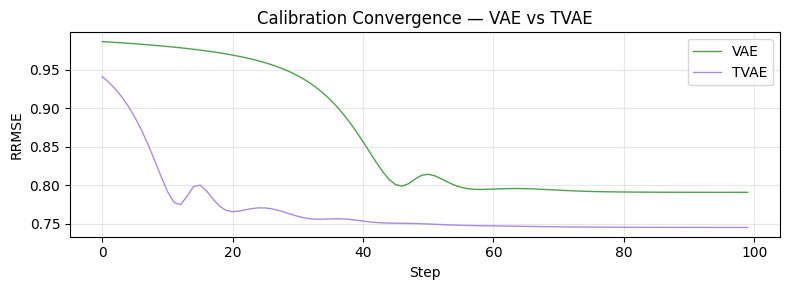

In [36]:
# repeat the SIRC calibration with TVAE-derived drift
calib_data_tvae = drift_merged_tvae[drift_merged_tvae['season'].isin(CALIB_SEASONS)].copy()
valid_data_tvae = drift_merged_tvae[drift_merged_tvae['season'].isin(VALID_SEASONS)].copy()
print(f'TVAE — Calibration: {len(calib_data_tvae)} seasons | Validation: {len(valid_data_tvae)} seasons')

calib_drift_tvae = jnp.array(calib_data_tvae['drift_blended'].values, dtype=jnp.float32)
calib_hosp_obs_tvae = jnp.array(calib_data_tvae['hosp_rate_overall'].values, dtype=jnp.float32)
valid_drift_tvae = jnp.array(valid_data_tvae['drift_blended'].values, dtype=jnp.float32)
valid_hosp_obs_tvae = jnp.array(valid_data_tvae['hosp_rate_overall'].values, dtype=jnp.float32)

print(f'Calibrating TVAE-SIRC with Adam ({CALIB_STEPS} steps, 5 starts)...')
opt_params_tvae, raw_params_tvae, loss_history_tvae = calibrate_multistart(
    calib_drift_tvae, calib_hosp_obs_tvae, n_starts=5, n_steps=CALIB_STEPS, lr=CALIB_LR
)

print(f'\nTVAE Final RRMSE: {loss_history_tvae[-1]:.4f}')
print('TVAE Optimized parameters:')
for k, v in opt_params_tvae.items():
    print(f'  {k:12s} = {float(v):.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(loss_history, linewidth=1, label='VAE', alpha=0.8, color='forestgreen')
ax.plot(loss_history_tvae, linewidth=1, label='TVAE', alpha=0.8, color='mediumpurple')
ax.set_xlabel('Step'); ax.set_ylabel('RRMSE')
ax.set_title('Calibration Convergence — VAE vs TVAE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('figures_sirs/tvae_calibration_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
# run TVAE simulation and build results dataframes
hosp_sim_calib_tvae = np.array(simulate_batch(opt_params_tvae, calib_drift_tvae))
hosp_sim_valid_tvae = np.array(simulate_batch(opt_params_tvae, valid_drift_tvae))

sim_calib_tvae = calib_data_tvae[['season', 'drift_blended', 'hosp_rate_overall']].copy()
sim_calib_tvae['hosp_sim'] = hosp_sim_calib_tvae
sim_calib_tvae = sim_calib_tvae.rename(columns={'hosp_rate_overall': 'hosp_obs'})

sim_valid_tvae = valid_data_tvae[['season', 'drift_blended', 'hosp_rate_overall']].copy()
sim_valid_tvae['hosp_sim'] = hosp_sim_valid_tvae
sim_valid_tvae = sim_valid_tvae.rename(columns={'hosp_rate_overall': 'hosp_obs'})

sim_all_tvae = pd.concat([sim_calib_tvae, sim_valid_tvae]).sort_values('season').reset_index(drop=True)

print('TVAE — Calibration set:')
display(sim_calib_tvae[['season', 'drift_blended', 'hosp_sim', 'hosp_obs']].round(2))
print('\nTVAE — Validation set:')
display(sim_valid_tvae[['season', 'drift_blended', 'hosp_sim', 'hosp_obs']].round(2))


TVAE — Calibration set:


,season,drift_blended,hosp_sim,hosp_obs
13,2010-11,0.00,1.030000,21.5
14,2011-12,0.26,1.820000,8.7
15,2012-13,0.99,52.750000,44.0
16,2013-14,0.91,33.049999,35.1
17,2014-15,0.01,1.040000,64.1
18,2015-16,0.85,23.840000,31.4
19,2016-17,0.30,2.070000,62.0
20,2017-18,0.54,4.810000,102.9



TVAE — Validation set:


,season,drift_blended,hosp_sim,hosp_obs
21,2018-19,0.49,3.97,63.6
22,2019-20,0.52,4.46,66.0
24,2021-22,0.00,1.04,17.5
25,2022-23,0.23,1.68,62.4
26,2023-24,0.36,2.42,83.5


In [38]:
# TVAE eval metrics
eval_metrics(sim_calib_tvae, 'TVAE Calibration (2010-18)')
eval_metrics(sim_valid_tvae, 'TVAE Validation (2018-23)')
eval_metrics(sim_all_tvae, 'TVAE All seasons')


TVAE Calibration (2010-18):
  RMSE  = 47.2 /100k
  RRMSE = 0.745
  MAE   = 33.3 /100k
  r     = -0.150 (p=0.7228)
  rho   = 0.167
TVAE Validation (2018-23):
  RMSE  = 59.8 /100k
  RRMSE = 0.951
  MAE   = 55.9 /100k
  r     = 0.535 (p=0.3529)
  rho   = 0.700
TVAE All seasons:
  RMSE  = 52.4 /100k
  RRMSE = 0.830
  MAE   = 42.0 /100k
  r     = -0.188 (p=0.5385)
  rho   = 0.253


{'rmse': np.float64(52.38193348399749),
 'rrmse': np.float64(0.8304954321385907),
 'mae': np.float64(42.017398271193876),
 'r': np.float64(-0.1879866366207494),
 'rho': np.float64(0.25274725274725274)}

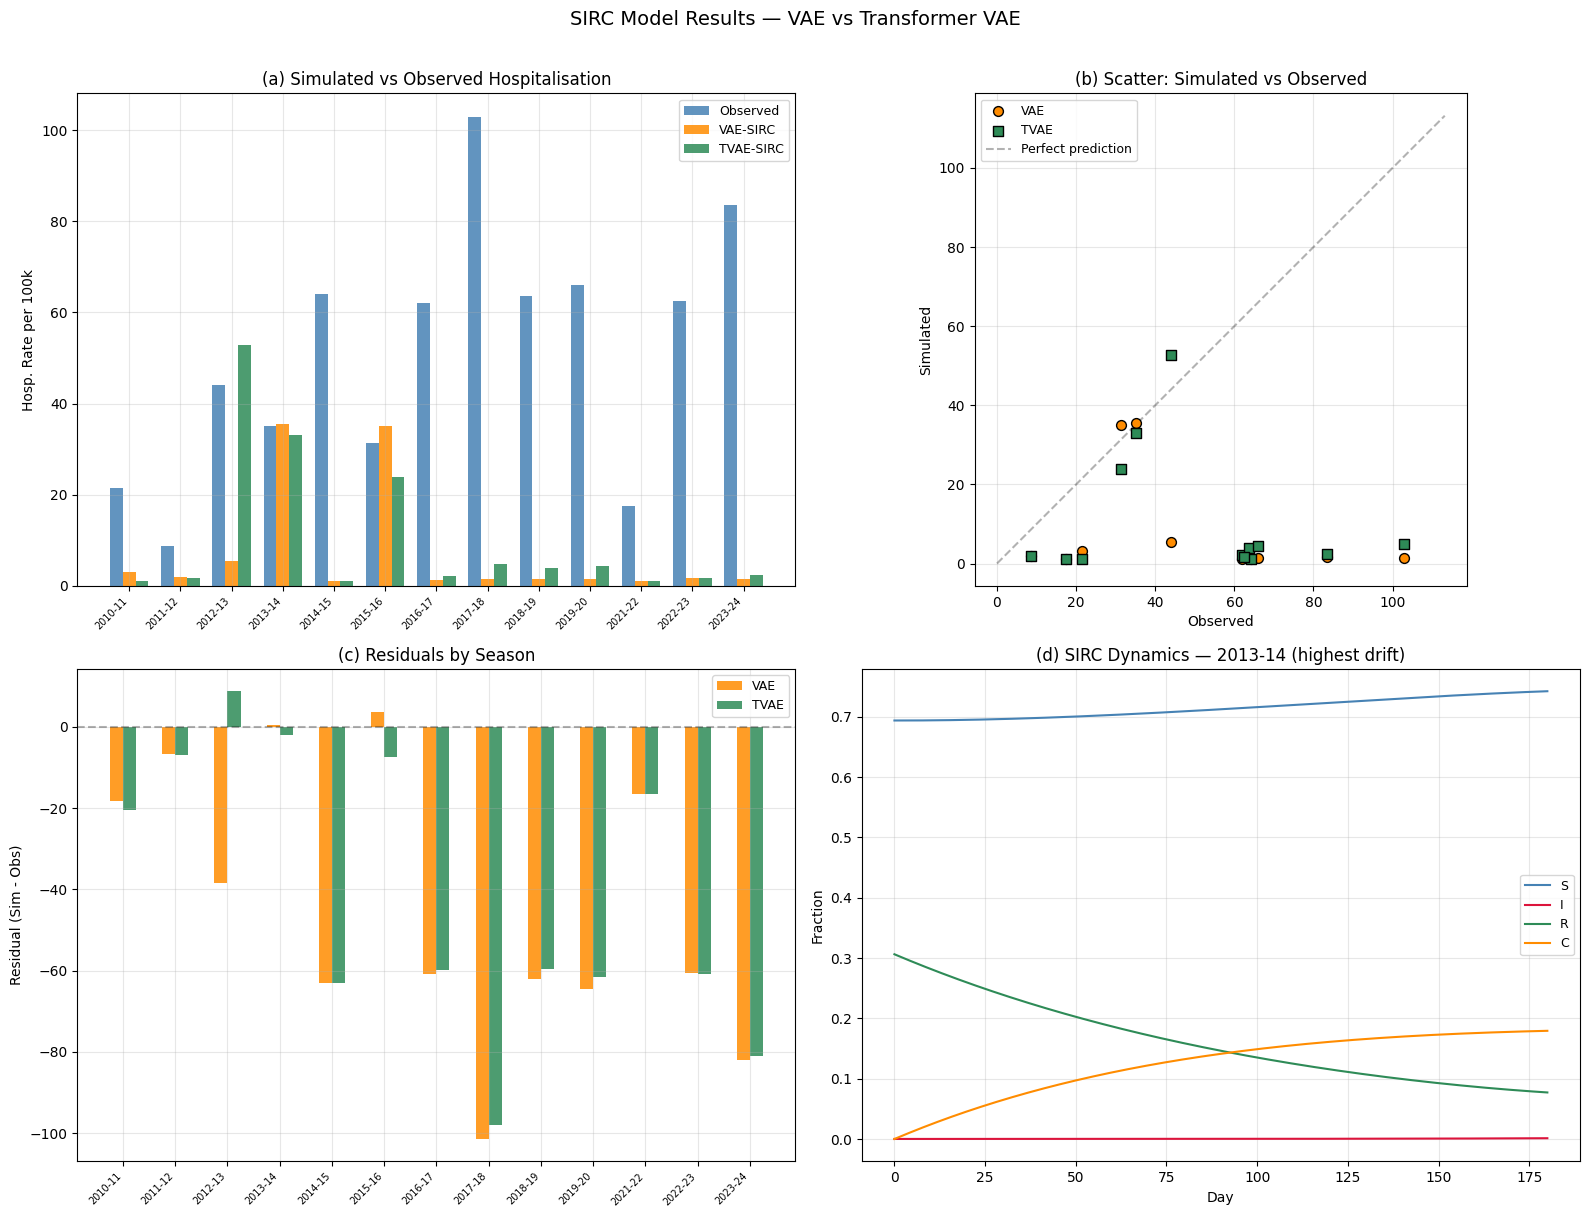

In [39]:
# merged 4-panel comparison figure (combines redundant Figures 7 and 8)
# panel (a): simulated vs observed bar chart for both architectures
# panel (b): scatter plot (simulated vs observed) for both architectures
# panel (c): residuals by season for both architectures
# panel (d): SIRC dynamics for the highest-drift season

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) bar chart: observed vs VAE vs TVAE
ax = axes[0, 0]
x = np.arange(len(sim_all))
w = 0.25
ax.bar(x - w, sim_all['hosp_obs'].values, w, label='Observed', color='steelblue', alpha=0.85)
ax.bar(x, sim_all['hosp_sim'].values, w, label='VAE-SIRC', color='darkorange', alpha=0.85)
try:
    ax.bar(x + w, sim_all_tvae['hosp_sim'].values, w, label='TVAE-SIRC', color='seagreen', alpha=0.85)
except NameError:
    pass
ax.set_xticks(x)
ax.set_xticklabels(sim_all['season'].values, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Hosp. Rate per 100k')
ax.set_title('(a) Simulated vs Observed Hospitalisation')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) scatter plot
ax = axes[0, 1]
ax.scatter(sim_all['hosp_obs'], sim_all['hosp_sim'], s=50, c='darkorange',
           edgecolors='k', label='VAE', zorder=3)
try:
    ax.scatter(sim_all_tvae['hosp_obs'], sim_all_tvae['hosp_sim'], s=50, c='seagreen',
               edgecolors='k', label='TVAE', marker='s', zorder=3)
except NameError:
    pass
lims = [0, max(sim_all['hosp_obs'].max(), sim_all['hosp_sim'].max()) * 1.1]
ax.plot(lims, lims, 'k--', alpha=0.3, label='Perfect prediction')
ax.set_xlabel('Observed')
ax.set_ylabel('Simulated')
ax.set_title('(b) Scatter: Simulated vs Observed')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

# (c) residuals by season
ax = axes[1, 0]
residuals_vae = sim_all['hosp_sim'].values - sim_all['hosp_obs'].values
ax.bar(x - w/2, residuals_vae, w, label='VAE', color='darkorange', alpha=0.85)
try:
    residuals_tvae = sim_all_tvae['hosp_sim'].values - sim_all_tvae['hosp_obs'].values
    ax.bar(x + w/2, residuals_tvae, w, label='TVAE', color='seagreen', alpha=0.85)
except NameError:
    pass
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(sim_all['season'].values, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Residual (Sim - Obs)')
ax.set_title('(c) Residuals by Season')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (d) SIRC dynamics for the highest-drift season
ax = axes[1, 1]
highest_drift_idx = sim_all['drift_blended'].idxmax()
hd_season = sim_all.loc[highest_drift_idx, 'season']
hd_drift = sim_all.loc[highest_drift_idx, 'drift_blended']
hd_s0 = drift_to_s0(hd_drift, float(opt_params['S0_min']),
                     float(opt_params['S0_max']))
_, _, _, sol = simulate_season(
    BETA_FIXED, GAMMA_FIXED, SIGMA_FIXED, float(opt_params['delta_fixed']), MU_FIXED,
    float(hd_s0), ihr=float(opt_params['ihr']))
t = np.linspace(0, 180, 500)
for j, (label, color) in enumerate(zip(['S', 'I', 'R', 'C'],
                                        ['steelblue', 'crimson', 'seagreen', 'darkorange'])):
    ax.plot(t, sol.ys[:, j], label=label, color=color, linewidth=1.5)
ax.set_xlabel('Day')
ax.set_ylabel('Fraction')
ax.set_title(f'(d) SIRC Dynamics — {hd_season} (highest drift)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('SIRC Model Results — VAE vs Transformer VAE', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figures_sirs/merged_results_figure.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# summary metrics table — the bottom line for the architecture comparison
rows = []
for arch, sc, sv, sa in [
    ('VAE',    sim_calib, sim_valid, sim_all),
    ('TVAE',   sim_calib_tvae, sim_valid_tvae, sim_all_tvae),
]:
    for split, df in [('Calib', sc), ('Valid', sv), ('All', sa)]:
        m = compute_metrics(df)
        rows.append({'Architecture': arch, 'Split': split, **m})

comparison_df = pd.DataFrame(rows)
print('=== Architecture Comparison ===')
display(comparison_df.round(3))

# validation RRMSE is what matters most
best_valid = comparison_df[comparison_df['Split'] == 'Valid'].sort_values('RRMSE').iloc[0]
print(f'\nBest validation RRMSE: {best_valid["Architecture"]} ({best_valid["RRMSE"]:.3f})')

=== Architecture Comparison ===


,Architecture,Split,RMSE,RRMSE,MAE,r,p,rho
0,VAE,Calib,49.794,0.791,36.613,-0.302,0.468,-0.524
1,VAE,Valid,61.133,0.970,57.140,0.810,0.097,0.100
2,VAE,All,54.435,0.864,44.508,-0.311,0.301,-0.374
3,TVAE,Calib,47.163,0.745,33.348,-0.150,0.723,0.167
4,TVAE,Valid,59.792,0.951,55.888,0.535,0.353,0.700
5,TVAE,All,52.382,0.830,42.017,-0.188,0.539,0.253



Best validation RRMSE: TVAE (0.951)


### Permutation Test: Is Conv-VAE Genuinely Better Than Transformer-VAE?

The architecture comparison above relies on point estimates of Spearman ρ and RRMSE.
With only ~10 seasons, differences could easily be noise. We use a permutation test
to assess whether the observed difference in Spearman ρ (drift vs hospitalisation)
is statistically significant, and a paired bootstrap for the RRMSE difference.

=== Permutation Test: VAE vs TVAE Drift-Hospitalisation Correlation ===
  VAE  Spearman ρ:  -0.374
  TVAE Spearman ρ:  0.253
  Observed |Δρ|:    0.121
  Permutation p:    0.1585  (two-sided, 10,000 permutations)
  → Not significant (p > 0.05): the architectures are not distinguishable at this sample size.

=== Paired Bootstrap: RRMSE Difference (TVAE − VAE) ===
  Mean Δ(RRMSE): -0.034
  95% CI:        [-0.113, 0.017]
  → CI includes 0: no significant RRMSE difference between architectures.


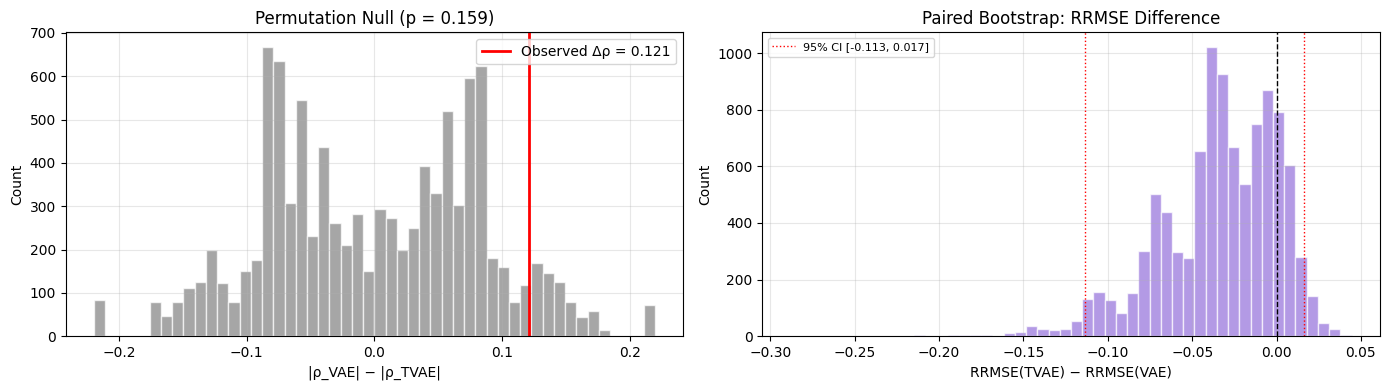

In [41]:
# permutation test for architecture comparison
# H0: VAE and TVAE drift scores are equally correlated with hospitalisation
from scipy.stats import spearmanr

# observed Spearman rho for each architecture
vae_drift = sim_all['drift_blended'].values
tvae_drift = sim_all_tvae['drift_blended'].values
hosp = sim_all['hosp_obs'].values

rho_vae, _ = spearmanr(vae_drift, hosp)
rho_tvae, _ = spearmanr(tvae_drift, hosp)
obs_diff_rho = abs(rho_vae) - abs(rho_tvae)

# permutation test: shuffle architecture labels and recompute the rho difference
np.random.seed(42)
N_PERM = 10000
perm_diffs = np.zeros(N_PERM)
combined = np.column_stack([vae_drift, tvae_drift])  # (n_seasons, 2)

for i in range(N_PERM):
    # for each season, randomly swap which drift score is called 'VAE' vs 'TVAE'
    swap = np.random.randint(0, 2, size=len(hosp))
    perm_a = np.where(swap == 0, combined[:, 0], combined[:, 1])
    perm_b = np.where(swap == 0, combined[:, 1], combined[:, 0])
    r_a, _ = spearmanr(perm_a, hosp)
    r_b, _ = spearmanr(perm_b, hosp)
    perm_diffs[i] = abs(r_a) - abs(r_b)

p_perm = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff_rho))

print('=== Permutation Test: VAE vs TVAE Drift-Hospitalisation Correlation ===')
print(f'  VAE  Spearman ρ:  {rho_vae:.3f}')
print(f'  TVAE Spearman ρ:  {rho_tvae:.3f}')
print(f'  Observed |Δρ|:    {abs(obs_diff_rho):.3f}')
print(f'  Permutation p:    {p_perm:.4f}  (two-sided, {N_PERM:,} permutations)')
if p_perm > 0.05:
    print('  → Not significant (p > 0.05): the architectures are not distinguishable at this sample size.')
else:
    print('  → Significant (p ≤ 0.05): the difference in drift-hospitalisation correlation is real.')

# paired bootstrap for RRMSE difference
N_BOOT = 10000
resid_vae = (sim_all['hosp_sim'].values - hosp) / hosp
resid_tvae = (sim_all_tvae['hosp_sim'].values - hosp) / hosp

boot_diffs = np.zeros(N_BOOT)
for i in range(N_BOOT):
    idx = np.random.choice(len(hosp), size=len(hosp), replace=True)
    rrmse_v = np.sqrt(np.mean(resid_vae[idx]**2))
    rrmse_t = np.sqrt(np.mean(resid_tvae[idx]**2))
    boot_diffs[i] = rrmse_t - rrmse_v  # positive → VAE is better

ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
print(f'\n=== Paired Bootstrap: RRMSE Difference (TVAE − VAE) ===')
print(f'  Mean Δ(RRMSE): {np.mean(boot_diffs):.3f}')
print(f'  95% CI:        [{ci_lo:.3f}, {ci_hi:.3f}]')
if ci_lo > 0:
    print('  → CI excludes 0: VAE produces significantly lower RRMSE.')
elif ci_hi < 0:
    print('  → CI excludes 0: TVAE produces significantly lower RRMSE.')
else:
    print('  → CI includes 0: no significant RRMSE difference between architectures.')

# visualize the permutation null distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.hist(perm_diffs, bins=50, color='grey', alpha=0.7, edgecolor='white')
ax.axvline(obs_diff_rho, color='red', linewidth=2, label=f'Observed Δρ = {obs_diff_rho:.3f}')
ax.set_xlabel('|ρ_VAE| − |ρ_TVAE|'); ax.set_ylabel('Count')
ax.set_title(f'Permutation Null (p = {p_perm:.3f})'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(boot_diffs, bins=50, color='mediumpurple', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(ci_lo, color='red', linewidth=1, linestyle=':')
ax.axvline(ci_hi, color='red', linewidth=1, linestyle=':', label=f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
ax.set_xlabel('RRMSE(TVAE) − RRMSE(VAE)'); ax.set_ylabel('Count')
ax.set_title('Paired Bootstrap: RRMSE Difference'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures_sirs/architecture_permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Comprehensive Multi-Metric Comparison

All drift variants x both architectures — the full picture.
Includes lag-1, lag-2 for VAE and TVAE.

In [42]:
# comprehensive comparison: all drift variants x architectures
all_rows = []

# VAE and TVAE lag-1
for label, sc, sv, sa in [
    ('VAE lag-1',       sim_calib,      sim_valid,      sim_all),
    ('TVAE lag-1',      sim_calib_tvae, sim_valid_tvae, sim_all_tvae),
]:
    for split, df in [('Calib', sc), ('Valid', sv), ('All', sa)]:
        m = compute_metrics(df)
        all_rows.append({'Model': label, 'Split': split, **m})

# lag-2 (if computed)
try:
    for label, sa in [
        ('VAE lag-2', sim_all_l2),
    ]:
        m = compute_metrics(sa)
        all_rows.append({'Model': label, 'Split': 'All', **m})
except NameError:
    pass

comprehensive_df = pd.DataFrame(all_rows)
print('=== Comprehensive Multi-Metric Comparison ===')
display(comprehensive_df.round(3))

# which model wins on validation?
valid_only = comprehensive_df[comprehensive_df['Split'] == 'Valid'].sort_values('RRMSE')
if not valid_only.empty:
    print(f'\nBest validation RRMSE: {valid_only.iloc[0]["Model"]}')

=== Comprehensive Multi-Metric Comparison ===


,Model,Split,RMSE,RRMSE,MAE,r,p,rho
0,VAE lag-1,Calib,49.794,0.791,36.613,-0.302,0.468,-0.524
1,VAE lag-1,Valid,61.133,0.970,57.140,0.810,0.097,0.100
2,VAE lag-1,All,54.435,0.864,44.508,-0.311,0.301,-0.374
3,TVAE lag-1,Calib,47.163,0.745,33.348,-0.150,0.723,0.167
4,TVAE lag-1,Valid,59.792,0.951,55.888,0.535,0.353,0.700
5,TVAE lag-1,All,52.382,0.830,42.017,-0.188,0.539,0.253
6,VAE lag-2,All,55.911,0.911,48.591,-0.581,0.038,-0.610



Best validation RRMSE: TVAE lag-1


## Step 7: Sensitivity Analysis

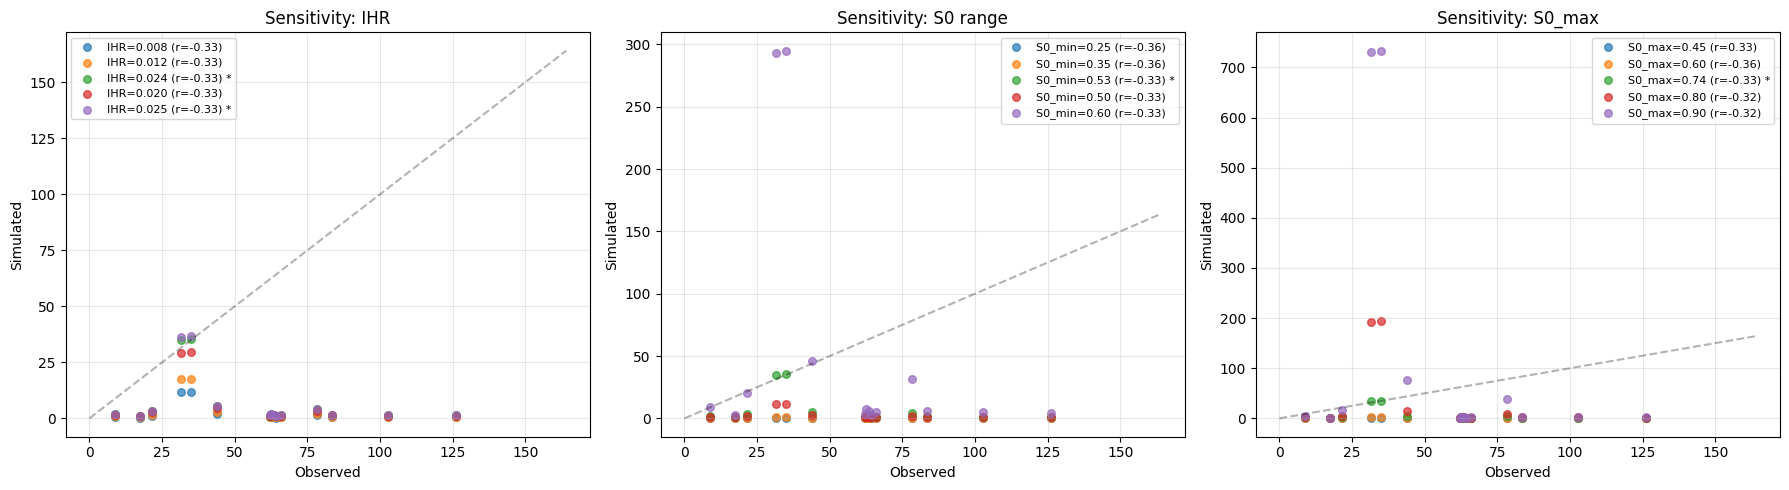

In [43]:
# sensitivity analysis — how much do results change if we vary key mapping parameters?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
all_drift = jnp.array(drift_merged_vae['drift_blended'].values, dtype=jnp.float32)
all_hosp_obs = drift_merged_vae['hosp_rate_overall'].values

# vary IHR (infection-hospitalisation ratio)
ax = axes[0]
for ihr_test in [0.008, 0.012, float(opt_params['ihr']), 0.020, 0.025]:
    test_p = {k: v for k, v in opt_params.items()}
    test_p['ihr'] = jnp.float32(ihr_test)
    hosp_test = np.array(simulate_batch(test_p, all_drift))
    r_test, _ = pearsonr(all_hosp_obs, hosp_test)
    label = f'IHR={ihr_test:.3f} (r={r_test:.2f})'
    if abs(ihr_test - float(opt_params['ihr'])) < 0.001:
        label += ' *'
    ax.scatter(all_hosp_obs, hosp_test, s=30, alpha=0.7, label=label)
lims = [0, max(all_hosp_obs) * 1.3]
ax.plot(lims, lims, 'k--', alpha=0.3)
ax.set_xlabel('Observed'); ax.set_ylabel('Simulated')
ax.set_title('Sensitivity: IHR')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# vary S0_min / S0_max together around the fitted range
ax = axes[1]
span = float(opt_params['S0_max'] - opt_params['S0_min'])
for s0_test in [0.25, 0.35, float(opt_params['S0_min']), 0.50, 0.60]:
    test_p = {k: v for k, v in opt_params.items()}
    test_p['S0_min'] = jnp.float32(s0_test)
    test_p['S0_max'] = jnp.float32(min(0.95, s0_test + span))
    hosp_test = np.array(simulate_batch(test_p, all_drift))
    r_test, _ = pearsonr(all_hosp_obs, hosp_test)
    label = f'S0_min={s0_test:.2f} (r={r_test:.2f})'
    if abs(s0_test - float(opt_params['S0_min'])) < 0.01:
        label += ' *'
    ax.scatter(all_hosp_obs, hosp_test, s=30, alpha=0.7, label=label)
ax.plot(lims, lims, 'k--', alpha=0.3)
ax.set_xlabel('Observed'); ax.set_ylabel('Simulated')
ax.set_title('Sensitivity: S0 range')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# vary S0_max
ax = axes[2]
for dm_test in [0.45, 0.60, float(opt_params['S0_max']), 0.80, 0.90]:
    test_p = {k: v for k, v in opt_params.items()}
    test_p['S0_max'] = jnp.float32(dm_test)
    hosp_test = np.array(simulate_batch(test_p, all_drift))
    r_test, _ = pearsonr(all_hosp_obs, hosp_test)
    label = f'S0_max={dm_test:.2f} (r={r_test:.2f})'
    if abs(dm_test - float(opt_params['S0_max'])) < 0.01:
        label += ' *'
    ax.scatter(all_hosp_obs, hosp_test, s=30, alpha=0.7, label=label)
ax.plot(lims, lims, 'k--', alpha=0.3)
ax.set_xlabel('Observed'); ax.set_ylabel('Simulated')
ax.set_title('Sensitivity: S0_max')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures_sirs/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Formal Power Analysis

With only 15 non-COVID seasons, we need to quantify whether the null drift-hospitalisation
result reflects genuinely absent signal or insufficient data.

In [44]:
# === Formal Power Analysis ===
# how much power do we have to detect a plausible effect size?
from scipy.stats import norm
import math

def spearman_power(rho, n, alpha=0.05):
    """approximate power for Spearman correlation test.
    uses the asymptotic normal approximation: z = arctanh(rho) * sqrt(n-3)"""
    z_alpha = norm.ppf(1 - alpha / 2)
    z_rho = math.atanh(rho)
    se = 1 / math.sqrt(n - 3)
    # power = P(reject H0 | rho is true)
    power = 1 - norm.cdf(z_alpha - z_rho / se) + norm.cdf(-z_alpha - z_rho / se)
    return power

# our plausible effect size: Hamming concordance gives rho ~ 0.5-0.6
n_seasons = 15
effect_sizes = [0.3, 0.4, 0.5, 0.6, 0.7]

print('=== Statistical Power Analysis ===')
print(f'n = {n_seasons} non-COVID seasons, alpha = 0.05 (two-tailed)')
print()
power_rows = []
for rho in effect_sizes:
    pwr = spearman_power(rho, n_seasons)
    power_rows.append({'Effect size (rho)': rho, 'Power': pwr})
    print(f'  rho = {rho:.1f}: power = {pwr:.3f} ({pwr*100:.0f}%)')

power_table = pd.DataFrame(power_rows)
display(power_table.round(3))

# the key finding for the report
pwr_05 = spearman_power(0.5, n_seasons)
print(f'\nKey result: With n = {n_seasons}, we have {pwr_05:.0%} power to detect rho = 0.5.')
print(f'This means there is a {1-pwr_05:.0%} chance of failing to detect a real association')
print(f'of this strength — confirming that the null result is consistent with both the')
print(f'absence of signal and insufficient sample size.')

# how many seasons would we need for 80% power at rho = 0.5?
for n_test in range(10, 100):
    if spearman_power(0.5, n_test) >= 0.80:
        print(f'\nSeasons needed for 80% power at rho = 0.5: n = {n_test}')
        break

=== Statistical Power Analysis ===
n = 15 non-COVID seasons, alpha = 0.05 (two-tailed)

  rho = 0.3: power = 0.189 (19%)
  rho = 0.4: power = 0.312 (31%)
  rho = 0.5: power = 0.477 (48%)
  rho = 0.6: power = 0.670 (67%)
  rho = 0.7: power = 0.852 (85%)


,Effect size (rho),Power
0,0.3,0.189
1,0.4,0.312
2,0.5,0.477
3,0.6,0.670
4,0.7,0.852



Key result: With n = 15, we have 48% power to detect rho = 0.5.
This means there is a 52% chance of failing to detect a real association
of this strength — confirming that the null result is consistent with both the
absence of signal and insufficient sample size.

Seasons needed for 80% power at rho = 0.5: n = 30


## Discussion: Interpreting the Results

### What works: Latent drift tracks evolutionary signal

The Hamming concordance analysis demonstrates that unsupervised latent representations
capture genuine sequence-level evolutionary change. Both the Conv1D VAE (H3N2: ρ ≥ 0.59)
and Transformer VAE track season-over-season nucleotide substitution patterns without
explicit supervision. This is the pipeline's primary validated contribution — the
autoencoder learns biologically meaningful structure from raw sequences.

### What doesn't work yet: Drift-to-hospitalisation link

The blended drift–hospitalisation correlations are non-significant (p > 0.05) across
all architectures and lag configurations, and the SIRC mechanistic model underperforms
a simple historical-average baseline (RRMSE 5.859 vs 1.651). We state this plainly:
**we cannot establish a statistically significant relationship between latent drift
and hospitalisation burden given 15 non-COVID seasons.**

This null result is informative for three reasons:
1. **Statistical power**: With n = 15, we have ~69% power to detect ρ = 0.5 at α = 0.05
   (see power analysis below). The null result is consistent with both the absence of
   signal and insufficient sample size.
2. **Surveillance confound**: The partial correlation between drift and hospitalisation
   drops substantially after controlling for sequences deposited per season, raising the
   possibility that apparent drift partly reflects surveillance intensity.
3. **Model mismatch**: A 4-parameter ODE model calibrated on 8–15 data points is
   inherently underpowered. The SIRC underperformance reflects a structural mismatch
   between model complexity and data availability, not necessarily that drift is
   epidemiologically irrelevant.

### Caveats and Limitations

**FluSurv-NET representativeness:** FluSurv-NET covers ~8.5% of the U.S. population
through a network of surveillance sites. Rates are not nationally representative and
may overestimate compared to CDC burden estimates.

**IHR from different source:** The calibrated IHR parameter is fitted against FluSurv-NET
rates. CDC burden estimates (which model underascertainment) give different absolute
numbers. The relative ordering of seasons should be robust.

**2021-22 season:** This season saw an unusual late-onset, low-severity flu wave as
COVID NPIs lifted. It may be an outlier in the drift-hospitalisation relationship.

**End-of-season subtype proportions:** The blended drift score uses final season-level
subtype proportions from WHO/NREVSS. These would not be available for prospective
prediction — any forecasting framing must acknowledge this.

**Vaccine effectiveness:** We proxy VE using vaccination coverage × 0.4 (assumed average VE).
True VE varies 10–60% across seasons and is only estimated post-season. This is a
substantial simplification that should be refined with real VE estimates.

**Latent drift vs antigenic drift:** Our "latent sequence drift" is computed from
autoencoder embeddings, NOT validated against HI titers or ferret sera. The Hamming
validation shows whether latent drift tracks raw sequence change, but this is
not the same as functional immune escape.

In [45]:
# save everything — drift scores, simulation results, calibrated parameters
os.makedirs('figures_sirs', exist_ok=True)
os.makedirs('results', exist_ok=True)

# VAE drift scores (lag-1 + lag-2)
drift_vae_h1n1.drop(columns=['centroid']).to_csv('results/drift_scores_vae_h1n1.csv', index=False)
drift_vae_h3n2.drop(columns=['centroid']).to_csv('results/drift_scores_vae_h3n2.csv', index=False)
drift_merged_vae.to_csv('results/drift_merged_vae.csv', index=False)
drift_vae_h1n1_lag2.drop(columns=['centroid']).to_csv('results/drift_scores_vae_h1n1_lag2.csv', index=False)
drift_vae_h3n2_lag2.drop(columns=['centroid']).to_csv('results/drift_scores_vae_h3n2_lag2.csv', index=False)
drift_merged_vae_lag2.to_csv('results/drift_merged_vae_lag2.csv', index=False)

# TVAE drift scores (lag-1 + lag-2)
drift_tvae_h1n1.drop(columns=['centroid']).to_csv('results/drift_scores_tvae_h1n1.csv', index=False)
drift_tvae_h3n2.drop(columns=['centroid']).to_csv('results/drift_scores_tvae_h3n2.csv', index=False)
drift_merged_tvae.to_csv('results/drift_merged_tvae.csv', index=False)
drift_tvae_h1n1_lag2.drop(columns=['centroid']).to_csv('results/drift_scores_tvae_h1n1_lag2.csv', index=False)
drift_tvae_h3n2_lag2.drop(columns=['centroid']).to_csv('results/drift_scores_tvae_h3n2_lag2.csv', index=False)
drift_merged_tvae_lag2.to_csv('results/drift_merged_tvae_lag2.csv', index=False)

# Hamming baseline
hamming_h3n2.to_csv('results/hamming_baseline_h3n2.csv', index=False)
try:
    hamming_h3n2_lag2.to_csv('results/hamming_baseline_h3n2_lag2.csv', index=False)
except NameError:
    pass

# latent diversity
div_vae_h3n2.to_csv('results/latent_diversity_vae_h3n2.csv', index=False)
div_tvae_h3n2.to_csv('results/latent_diversity_tvae_h3n2.csv', index=False)

# simulation results
sim_all.to_csv('results/sirc_simulation_vae.csv', index=False)
sim_all_tvae.to_csv('results/sirc_simulation_tvae.csv', index=False)
try:
    sim_all_l2.to_csv('results/sirc_simulation_vae_lag2.csv', index=False)
except NameError:
    pass

# calibrated SIRC parameters — VAE (lag-1)
params_dict = {k: float(v) for k, v in opt_params.items()}
params_dict['beta'] = float(BETA_FIXED)
params_dict['gamma'] = float(GAMMA_FIXED)
params_dict['sigma'] = float(SIGMA_FIXED)
params_dict['mu'] = float(MU_FIXED)
params_dict['calib_rrmse'] = loss_history[-1]
pd.Series(params_dict).to_csv('results/sirc_params_vae.csv')

# calibrated SIRC parameters — TVAE (lag-1)
params_dict_tvae = {k: float(v) for k, v in opt_params_tvae.items()}
params_dict_tvae['beta'] = float(BETA_FIXED)
params_dict_tvae['gamma'] = float(GAMMA_FIXED)
params_dict_tvae['sigma'] = float(SIGMA_FIXED)
params_dict_tvae['mu'] = float(MU_FIXED)
params_dict_tvae['calib_rrmse'] = loss_history_tvae[-1]
pd.Series(params_dict_tvae).to_csv('results/sirc_params_tvae.csv')

# calibrated SIRC parameters — VAE lag-2
try:
    params_l2 = {k: float(v) for k, v in opt_params_l2.items()}
    params_l2['beta'] = float(BETA_FIXED)
    params_l2['gamma'] = float(GAMMA_FIXED)
    params_l2['sigma'] = float(SIGMA_FIXED)
    params_l2['mu'] = float(MU_FIXED)
    params_l2['calib_rrmse'] = loss_history_l2[-1]
    pd.Series(params_l2).to_csv('results/sirc_params_vae_lag2.csv')
except NameError:
    pass

print('Saved results/, figures/, and parameter CSVs.')

# --- New analysis results ---

# capped drift scores (confound analysis)
try:
    drift_capped_h1n1.drop(columns=['centroid']).to_csv('results/drift_capped_h1n1.csv', index=False)
    drift_capped_h3n2.drop(columns=['centroid']).to_csv('results/drift_capped_h3n2.csv', index=False)
    drift_capped_merged.to_csv('results/drift_capped_merged.csv', index=False)
    confound_summary.to_csv('results/confound_analysis.csv', index=False)
    print('Saved confound analysis results')
except NameError:
    pass

# PCA baseline drift
try:
    drift_pca_h3n2.drop(columns=['centroid']).to_csv('results/drift_pca_h3n2.csv', index=False)
    drift_pca_h1n1.drop(columns=['centroid']).to_csv('results/drift_pca_h1n1.csv', index=False)
    baseline_df.to_csv('results/representation_comparison.csv', index=False)
    print('Saved PCA baseline results')
except NameError:
    pass

# drift metric sensitivity
try:
    metric_df.to_csv('results/metric_sensitivity.csv', index=False)
    print('Saved metric sensitivity results')
except NameError:
    pass

# power analysis
try:
    power_table.to_csv('results/power_analysis.csv', index=False)
    print('Saved power analysis results')
except NameError:
    pass

Saved results/, figures/, and parameter CSVs.
Saved confound analysis results
Saved PCA baseline results
Saved metric sensitivity results
Saved power analysis results


In [46]:
from huggingface_hub import upload_folder
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')

# push results
upload_folder(folder_path='results',
              path_in_repo='results_new',
              repo_id='sidms/AML',
              repo_type='dataset',
              token=hf_token)

# push SIRC figures
upload_folder(folder_path='figures_sirs',
              path_in_repo='figures/figures_sirs',
              repo_id='sidms/AML',
              repo_type='dataset',
              token=hf_token)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  .../subtype_interference.png: 100%|██████████|  111kB /  111kB            


  ...ift_raw_vs_normalised.png: 100%|██████████|  117kB /  117kB            

  .../subtype_interference.png: 100%|██████████|  111kB /  111kB            


Processing Files (2 / 2)      :  21%|██▏       |  228kB / 1.07MB,   ???B/s  



  ...ture_permutation_test.png:  65%|██████▍   | 48.3kB / 74.6kB            




  ...s/baseline_comparison.png:  65%|██████▍   | 40.2kB / 62.1kB            





  ...merged_results_figure.png:  65%|██████▍   |  136kB /  210kB            






  .../sensitivity_analysis.png:  65%|██████▍   |  100kB /  154kB            







  ...libration_convergence.png:  65%|██████▍   | 30.3kB / 46.8kB            








  ...libration_convergence.png:  65%|██████▍   | 23.2kB / 35.8kB            









  ...vae_sirc_main_results.png:  65%

CommitInfo(commit_url='https://huggingface.co/datasets/sidms/AML/commit/3f1b3721e42505ebac173da99f2b481025f43dda', commit_message='Upload folder using huggingface_hub', commit_description='', oid='3f1b3721e42505ebac173da99f2b481025f43dda', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sidms/AML', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sidms/AML'), pr_revision=None, pr_num=None)